# 1.Set-up

In [2]:
!pip install ydata-profiling
!pip install catboost
!pip install xgboost
!pip install -U imbalanced-learn
!pip install -U scikit-learn
!pip install -U scikit-learn==1.3.2 imbalanced-learn==0.11.0
!pip install lightgbm
!pip install keras
!pip install tensorflow
!pip install scikit-learn==0.24
!pip install lazypredict

  Using cached imbalanced_learn-0.14.1-py3-none-any.whl.metadata (8.9 kB)
  Using cached scikit_learn-1.8.0-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (11 kB)
Using cached imbalanced_learn-0.14.1-py3-none-any.whl (235 kB)
Using cached scikit_learn-1.8.0-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl (8.9 MB)
  Attempting uninstall: scikit-learn
    Found existing installation: scikit-learn 1.3.2
    Uninstalling scikit-learn-1.3.2:
      Successfully uninstalled scikit-learn-1.3.2
  Attempting uninstall: imbalanced-learn
    Found existing installation: imbalanced-learn 0.11.0
    Uninstalling imbalanced-learn-0.11.0:
      Successfully uninstalled imbalanced-learn-0.11.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
shap 0.51.0 requires numpy>=2, but you have numpy 1.26.4 which is incompatible.
tobler 0.14.0 requires nu

In [3]:
import pandas as pd
import sys
import ast
#from ydata_profiling import ProfileReport
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import warnings
import random
#from google.colab import files



from random import shuffle
from sklearn import preprocessing
from lazypredict.Supervised import LazyClassifier
from sklearn.model_selection import train_test_split,cross_val_score, learning_curve
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier,GradientBoostingClassifier, ExtraTreesClassifier, BaggingClassifier
from sklearn.tree import ExtraTreeClassifier
from sklearn.naive_bayes import GaussianNB, BernoulliNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.tree import DecisionTreeClassifier
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from sklearn.ensemble import StackingClassifier, VotingClassifier
from sklearn.metrics import confusion_matrix, classification_report, f1_score, accuracy_score, precision_score, recall_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder,LabelEncoder
from scipy.stats import norm, skew
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from keras import models, layers
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score


# Tensforflow libraries
import tensorflow as tf
from tensorflow import keras
from keras import Sequential
from tensorflow.keras.optimizers import Adam
from keras.layers import Flatten, Dense, Dropout, BatchNormalization
from keras.layers import Conv1D, MaxPool1D
%matplotlib inline


warnings.filterwarnings('ignore')

# 2.Data Loading

In [4]:
from google.colab import files
uploaded = files.upload()


Saving All.csv to All.csv
Saving All.csv.crdownload to All.csv.crdownload
Saving All_BestFirst.csv to All_BestFirst.csv
Saving All_BestFirst_test.csv to All_BestFirst_test.csv
Saving All_Infogain.csv.crdownload to All_Infogain.csv.crdownload
Saving All_Infogain_test.csv.crdownload to All_Infogain_test.csv.crdownload
Saving data_Features (2).csv to data_Features (2).csv
Saving Defacement.csv.crdownload to Defacement.csv.crdownload
Saving Defacement_BestFirst.csv.crdownload to Defacement_BestFirst.csv.crdownload
Saving Defacement_Infogain.csv.crdownload to Defacement_Infogain.csv.crdownload
Saving malicious_phish.csv to malicious_phish.csv
Saving Malware_BestFirst.csv to Malware_BestFirst.csv
Saving Malware_Infogain.csv to Malware_Infogain.csv
Saving Malware_Infogain_test.csv to Malware_Infogain_test.csv
Saving Phishing.csv to Phishing.csv
Saving Phishing_BestFirst.csv to Phishing_BestFirst.csv
Saving Phishing_Infogain.csv to Phishing_Infogain.csv
Saving Phishing_Infogain_test.csv to Phi

In [5]:
Dataset = pd.read_csv("data_Features (2).csv", on_bad_lines='skip', encoding='latin1')
Dataset.head()


,domain,ranking,mld_res,mld.ps_res,card_rem,ratio_Rrem,ratio_Arem,jaccard_RR,jaccard_RA,jaccard_AR,jaccard_AA,jaccard_ARrd,jaccard_ARrem,label
0,nobell.it/70ffb52d079109dca5664cce6f317373782/...,10000000,1.0,0.0,18.0,107.611111,107.277778,0.0,0.0,0.0,0.0,0.8,0.795729,1.0
1,www.dghjdgf.com/paypal.co.uk/cycgi-bin/webscrc...,10000000,0.0,0.0,11.0,150.636364,152.272727,0.0,0.0,0.0,0.0,0,0.768577,1.0
2,serviciosbys.com/paypal.cgi.bin.get-into.herf....,10000000,0.0,0.0,14.0,73.500000,72.642857,0.0,0.0,0.0,0.0,0,0.726582,1.0
3,mail.printakid.com/www.online.americanexpress....,10000000,0.0,0.0,6.0,562.000000,590.666667,0.0,0.0,0.0,0.0,0,0.85964,1.0
4,thewhiskeydregs.com/wp-content/themes/widescre...,10000000,0.0,0.0,8.0,29.000000,24.125000,0.0,0.0,0.0,0.0,0,0.748971,1.0


# 3.Data Analysis

In [6]:
Dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 96005 entries, 0 to 96004
Data columns (total 14 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   domain         96005 non-null  object 
 1   ranking        95953 non-null  object 
 2   mld_res        95935 non-null  object 
 3   mld.ps_res     95924 non-null  object 
 4   card_rem       95923 non-null  float64
 5   ratio_Rrem     95923 non-null  float64
 6   ratio_Arem     95923 non-null  float64
 7   jaccard_RR     95922 non-null  float64
 8   jaccard_RA     95921 non-null  float64
 9   jaccard_AR     95920 non-null  float64
 10  jaccard_AA     95919 non-null  float64
 11  jaccard_ARrd   95919 non-null  object 
 12  jaccard_ARrem  95917 non-null  object 
 13  label          95913 non-null  float64
dtypes: float64(8), object(6)
memory usage: 10.3+ MB


In [7]:
Dataset.nunique()

,0
domain,96003
ranking,8206
mld_res,21
mld.ps_res,10
card_rem,53
ratio_Rrem,10042
ratio_Arem,10231
jaccard_RR,5446
jaccard_RA,5628
jaccard_AR,5071


In [8]:
Dataset.describe()

,card_rem,ratio_Rrem,ratio_Arem,jaccard_RR,jaccard_RA,jaccard_AR,jaccard_AA,label
count,95923.000000,95923.000000,95923.000000,95922.000000,95921.000000,95920.000000,95919.000000,95913.000000
mean,4.580498,135.255201,138.544211,0.005030,0.003787,0.003378,0.003661,0.499453
std,4.466073,160.988895,175.480485,0.311308,0.024815,0.024011,0.028492,0.500002
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2.000000,43.000000,39.666667,0.000000,0.000000,0.000000,0.000000,0.000000
50%,3.000000,104.000000,103.333333,0.000000,0.000000,0.000000,0.000000,0.000000
75%,6.000000,174.142857,178.292857,0.000000,0.000000,0.000000,0.000000,1.000000
max,187.333333,5507.000000,6097.000000,96.000000,1.000000,1.000000,1.000000,1.000000


# 4.Feature engineering and data cleaning

In [9]:
# Get the number of rows and columns
num_rows, num_columns = Dataset.shape

# Print the results
print(f"Number of rows: {num_rows}")
print(f"Number of columns: {num_columns}")

Number of rows: 96005
Number of columns: 14


### Checking for Null values

In [10]:
print("Number of NULL values:\n", Dataset.isnull().sum())

Number of NULL values:
 domain            0
ranking          52
mld_res          70
mld.ps_res       81
card_rem         82
ratio_Rrem       82
ratio_Arem       82
jaccard_RR       83
jaccard_RA       84
jaccard_AR       85
jaccard_AA       86
jaccard_ARrd     86
jaccard_ARrem    88
label            92
dtype: int64


### Checking for Duplicate Rows

In [11]:
print("Number of Duplicate Rows:", Dataset.duplicated().sum())

Number of Duplicate Rows: 1


In [12]:
 # Dataset.drop_duplicates(inplace=True)
 # print("Number of Duplicate Rows after Removal:", Dataset.duplicated().sum())
 # Drop non-numeric column like domain if present
if "domain" in Dataset.columns:
    Dataset = Dataset.drop("domain", axis=1)

# Convert all columns to numeric, force errors → NaN
Dataset = Dataset.apply(pd.to_numeric, errors="coerce")

# Drop rows with NaN
Dataset = Dataset.dropna()

### Check outliers

In [13]:
numeric_columns = Dataset.select_dtypes(include=['number'])

# Extract column names
numeric_column_names = numeric_columns.columns.tolist()

# Print the names of numerical columns
print("Numerical Column Names:")
print(numeric_column_names)

Numerical Column Names:
['ranking', 'mld_res', 'mld.ps_res', 'card_rem', 'ratio_Rrem', 'ratio_Arem', 'jaccard_RR', 'jaccard_RA', 'jaccard_AR', 'jaccard_AA', 'jaccard_ARrd', 'jaccard_ARrem', 'label']


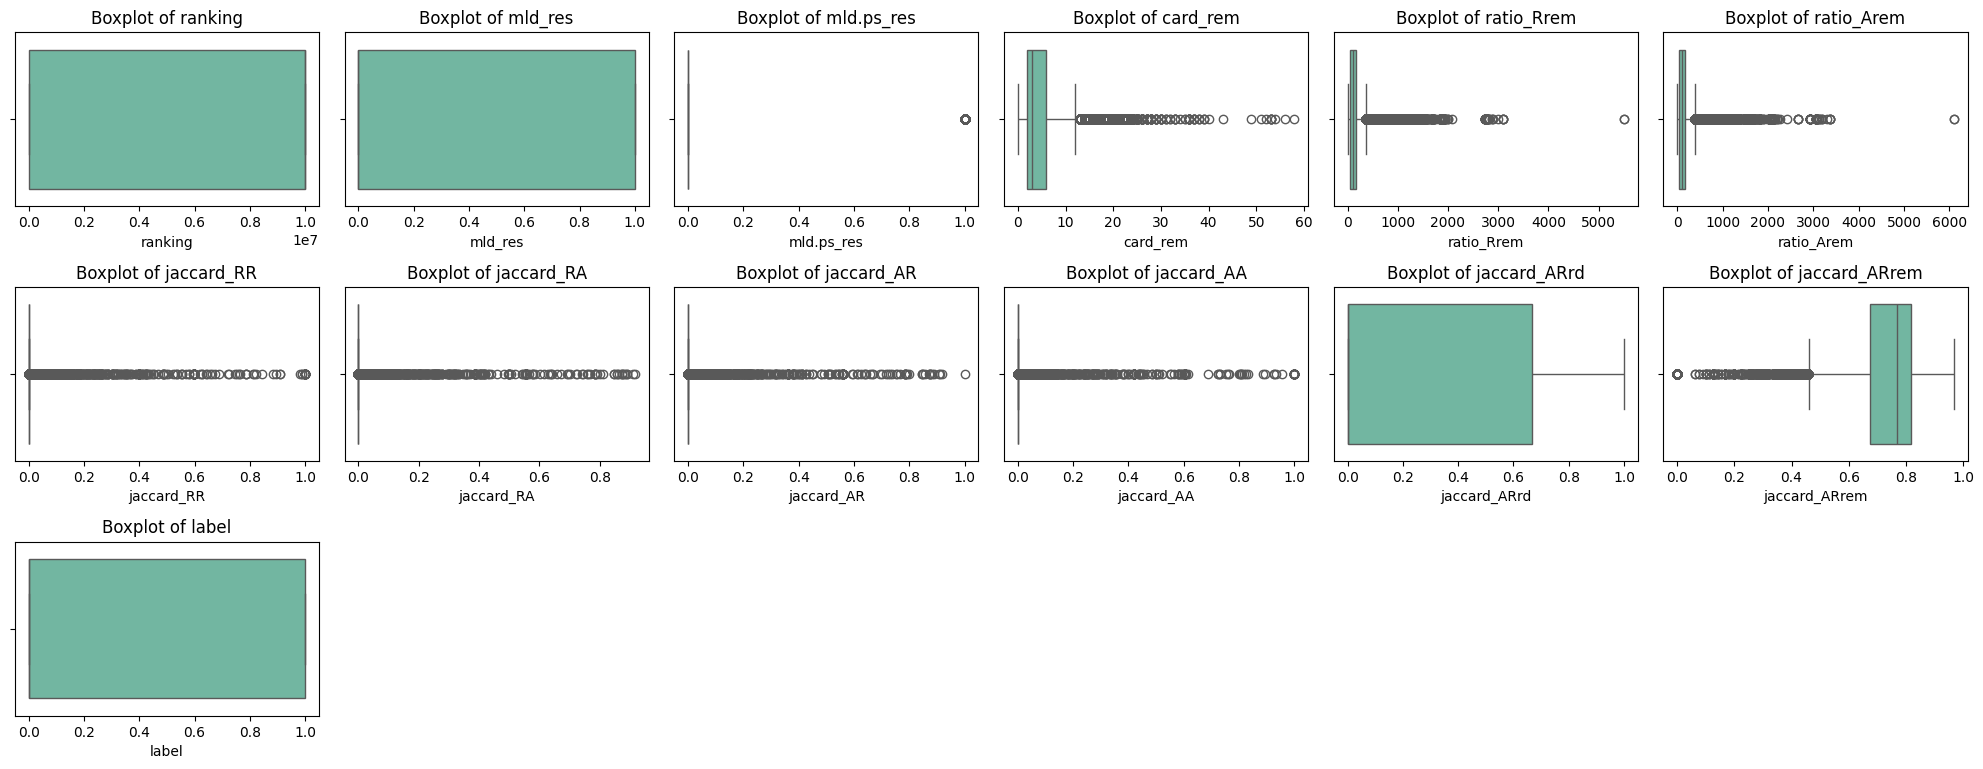

In [14]:
# Create separate boxplots for each numerical column
plt.figure(figsize=(20, 15))

for i, column in enumerate(numeric_column_names):
    plt.subplot(6, 6, i + 1)  # Adjust the subplot grid as needed
    sns.boxplot(x=column, data=Dataset, palette="Set2")
    plt.title(f"Boxplot of {column}")

plt.tight_layout()
plt.show()

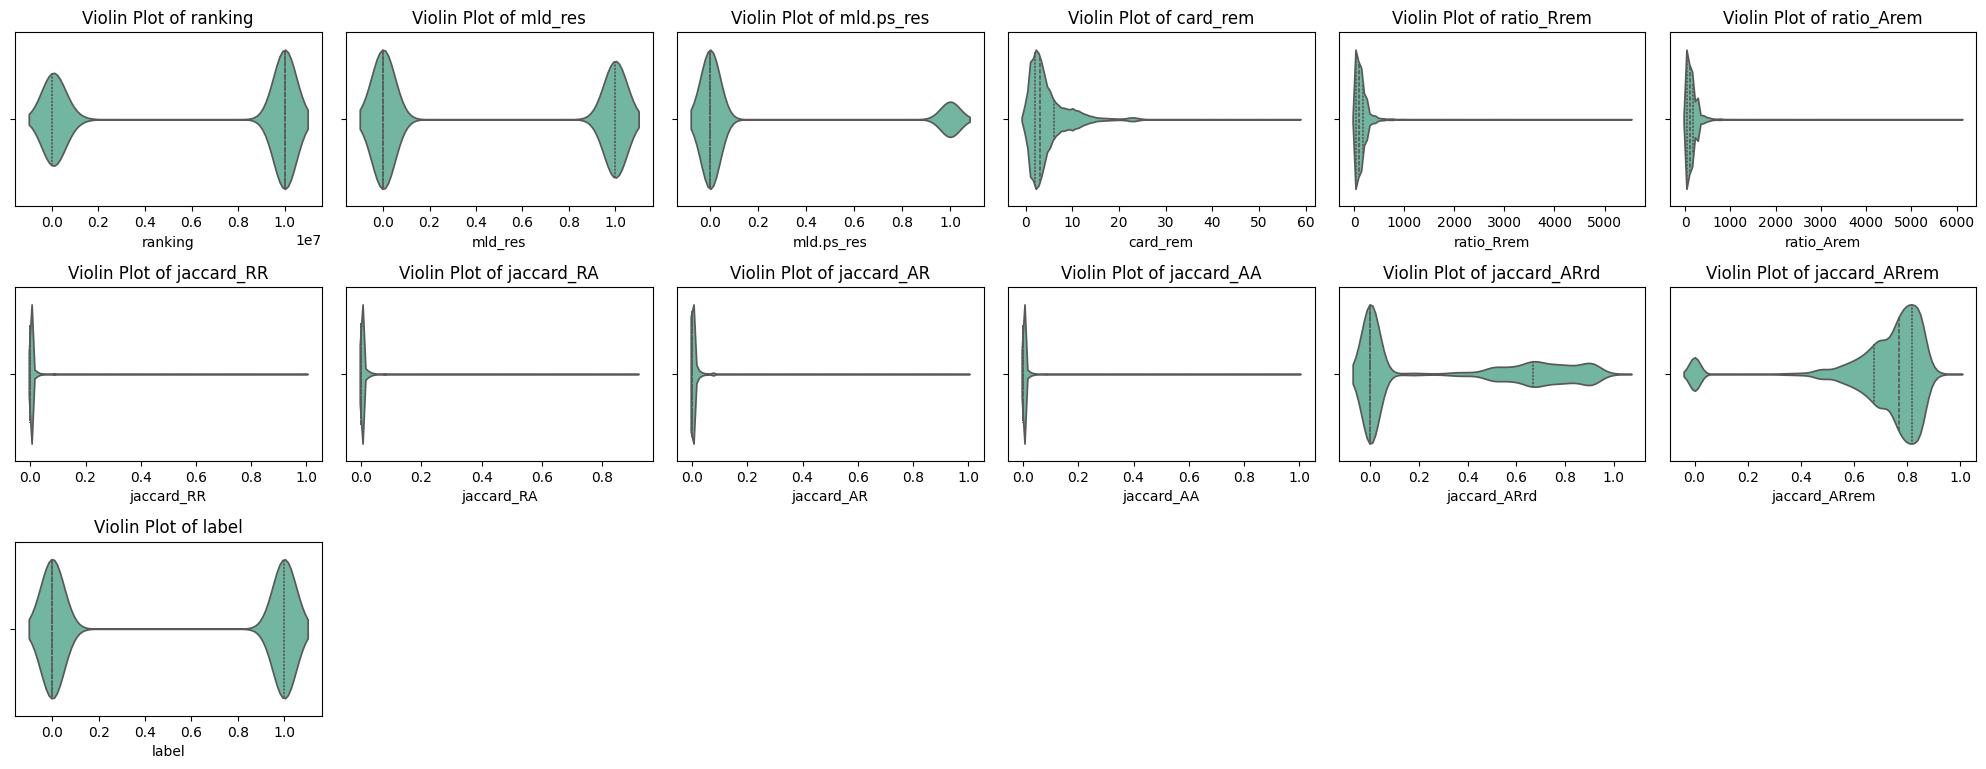

In [15]:
# Create separate violin plots for each numerical column
plt.figure(figsize=(20, 15))

for i, column in enumerate(numeric_column_names):
    plt.subplot(6, 6, i + 1)  # Adjust the subplot grid as needed
    sns.violinplot(x=column, data=Dataset, palette="Set2", inner="quartile")
    plt.title(f"Violin Plot of {column}")

plt.tight_layout()
plt.show()

## EDA

### Distribution graphs (Histograms)

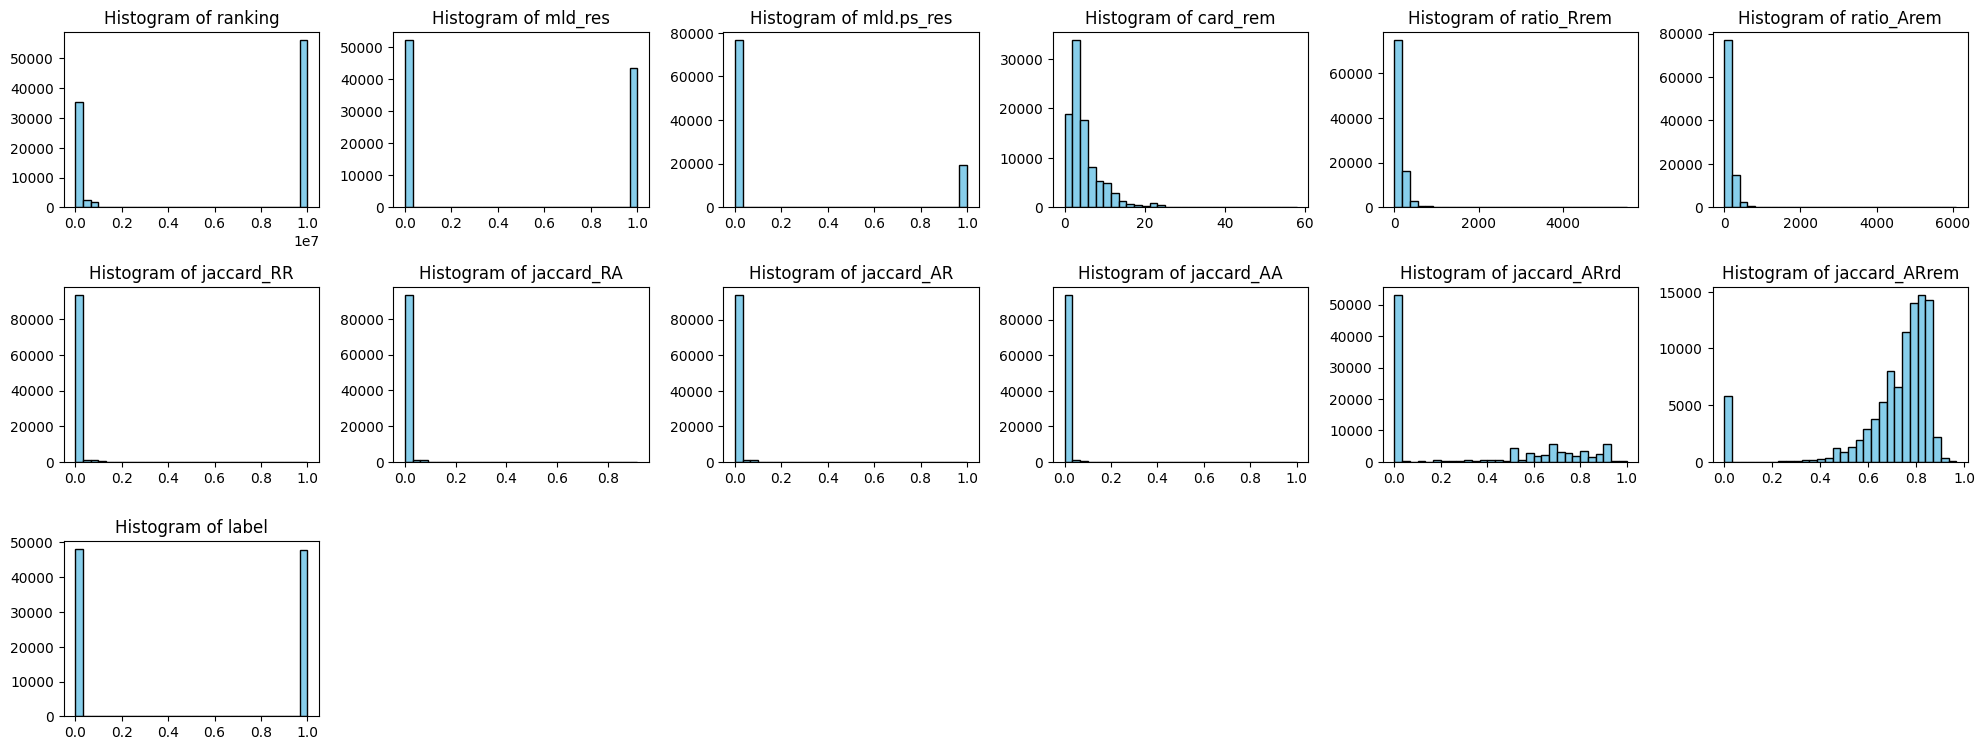

In [16]:
# Create separate histograms for each numerical column
plt.figure(figsize=(20, 15))

for i, column in enumerate(numeric_column_names):
    plt.subplot(6, 6, i + 1)  # Adjust the subplot grid as needed
    plt.hist(Dataset[column], bins=30, color='skyblue', edgecolor='black')
    plt.title(f"Histogram of {column}")

plt.tight_layout()
plt.show()

### Correlation matrix

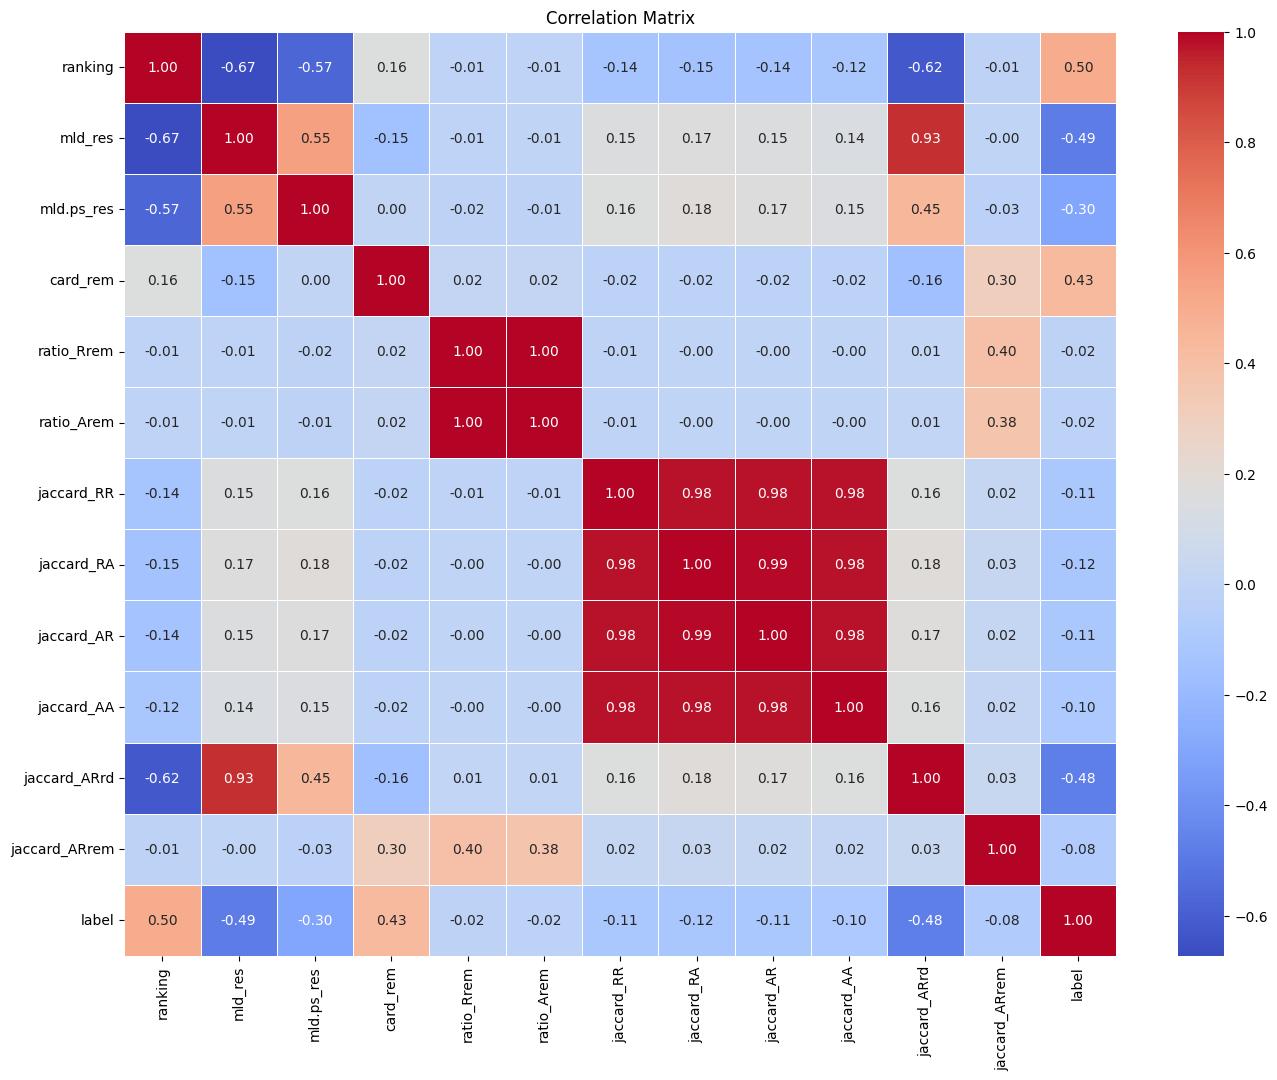

In [17]:
# Selecting only numerical columns
numeric_columns = Dataset[numeric_column_names]

# Calculate the correlation matrix
correlation_matrix = numeric_columns.corr()

# Plotting the correlation matrix using a heatmap
plt.figure(figsize=(16, 12))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=.5)
plt.title("Correlation Matrix")
plt.show()

### Balance or Non-Balance?
Number of Phishing(Attack) and Benign(Not-Attack)

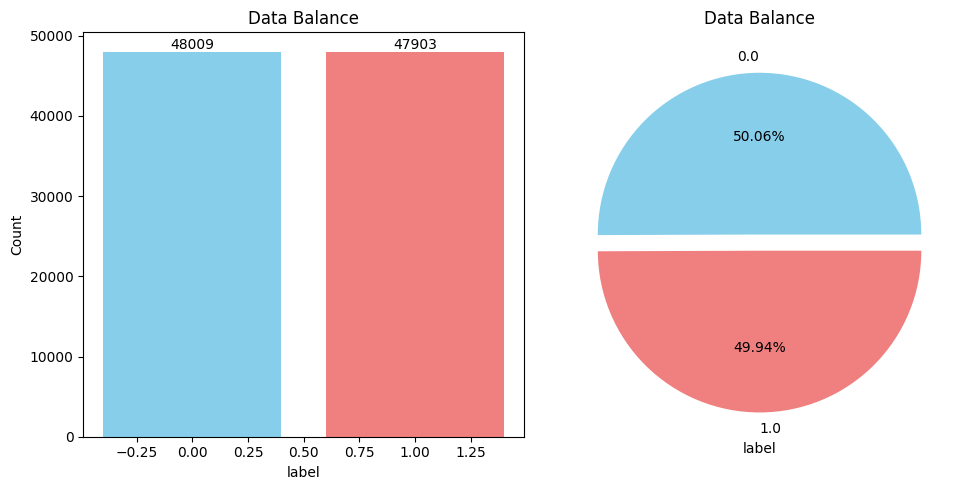

In [18]:
# Assuming S_dataset is your DataFrame
attack_counts = Dataset['label'].value_counts()

# Create a figure and a 1x2 subplot grid
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(10, 5))

# Bar plot on the first subplot
bars = axes[0].bar(attack_counts.index, attack_counts.values, color=['skyblue', 'lightcoral'])
axes[0].set_xlabel('label')
axes[0].set_ylabel('Count')
axes[0].set_title('Data Balance')

# Add count labels on top of each bar
for bar, count in zip(bars, attack_counts.values):
    axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height(), str(count),
                 ha='center', va='bottom')

# Pie chart on the second subplot
Dataset['label'].value_counts().plot.pie(explode=[0, 0.1], autopct='%1.2f%%', colors=['skyblue', 'lightcoral'], ax=axes[1])
axes[1].set_xlabel('label')
axes[1].set_ylabel('')  # Remove y-axis label for pie chart
axes[1].set_title('Data Balance')

# Adjust layout to prevent overlap
plt.tight_layout()

# Show the plot
plt.show()


In [19]:
# Extract features (X) and target variable (y)
X = Dataset.drop("label", axis=1) # X includes all columns except 'Type'
y = Dataset["label"]  # Target variable is 'Type'


### Identifying Features with Overwhelmingly Repeated Maximum Values

In [20]:
def identify_repeated_max(df):
    cols_to_drop = []  # Initialize a list to store column names to be dropped

    cols = df.columns.values
    for col in cols:
        max_count = df[col].value_counts().max()
        total = len(df)
        max_percentage = (max_count / total) * 100

        if max_percentage > 90:  # Check if repetition percentage is over 97%
            print(f"Feature '{col}' has the largest value repeated more than 70% of the time.")
            print(f"Largest value: {df[col].value_counts().idxmax()}")
            print(f"Repetition percentage: {max_percentage:.2f}%")
            print()
            cols_to_drop.append(col)  # Add the column to the list of columns to be dropped

    return cols_to_drop  # Return the list of column names to be dropped

In [21]:
# Call the function and get the list of columns to be dropped
columns_to_drop = identify_repeated_max(X)

print("Columns to be dropped:", columns_to_drop)

Columns to be dropped: []


In [22]:
cols_to_drop = identify_repeated_max(X)

X1 = X.drop(cols_to_drop, axis=1)

In [23]:
# Get the number of rows and columns
num_rows, num_columns = X1.shape

# Print the results
print(f"Number of rows: {num_rows}")
print(f"Number of columns: {num_columns}")

Number of rows: 95912
Number of columns: 12


### OverSampling
to make the data balance

In [24]:
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)


In [25]:
# Initialize SMOTE
smote = SMOTE(random_state=42)

# Apply SMOTE only to the training set
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)
# Now, X_train_resampled and y_train_resampled contain the resampled data with synthetic samples for the minority class


In [26]:
y_train_resampled

,label
0,1.0
1,1.0
2,1.0
3,1.0
4,0.0
...,...
76809,1.0
76810,1.0
76811,1.0
76812,1.0


### Balance or Non-Balance?
Number of Phishing(Attack) and Benign(Not-Attack)

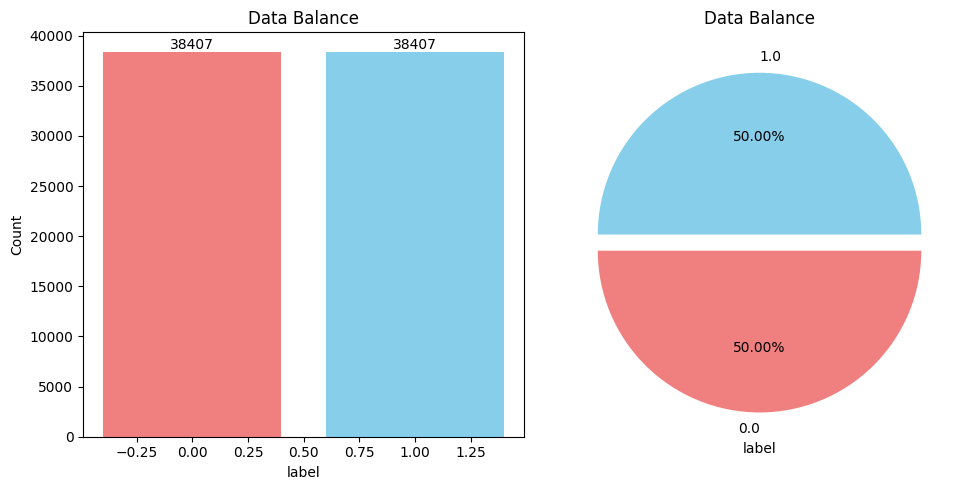

In [27]:
# Assuming S_dataset is your DataFrame
attack_counts = y_train_resampled.value_counts()

# Create a figure and a 1x2 subplot grid
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(10, 5))

# Bar plot on the first subplot
bars = axes[0].bar(attack_counts.index, attack_counts.values, color=['skyblue', 'lightcoral'])
axes[0].set_xlabel('label')
axes[0].set_ylabel('Count')
axes[0].set_title('Data Balance')

# Add count labels on top of each bar
for bar, count in zip(bars, attack_counts.values):
    axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height(), str(count),
                 ha='center', va='bottom')

# Pie chart on the second subplot
y_train_resampled.value_counts().plot.pie(explode=[0, 0.1], autopct='%1.2f%%', colors=['skyblue', 'lightcoral'], ax=axes[1])
axes[1].set_xlabel('label')
axes[1].set_ylabel('')  # Remove y-axis label for pie chart
axes[1].set_title('Data Balance')

# Adjust layout to prevent overlap
plt.tight_layout()

# Show the plot
plt.show()


In [28]:
print("Number of Duplicate Rows:", Dataset.duplicated().sum())

Number of Duplicate Rows: 38421


# 5.Modeling

### Apply LazyClassifier

In [29]:
# Disable GPU and clear memory
import os, gc, psutil
os.environ["CUDA_VISIBLE_DEVICES"] = ""  # Force CPU-only mode

# Function to show RAM usage
def show_ram_usage():
    print(f"RAM used: {psutil.virtual_memory().percent}%")

gc.collect()
show_ram_usage()

# Import LazyPredict and dependencies
!pip install lazypredict --quiet
from lazypredict.Supervised import LazyClassifier

# (Optional) Downsample large dataset for stability
# If your training data has >20k samples, reduce it temporarily.
if len(X_train_resampled) > 20000:
    import pandas as pd
    import numpy as np
    sample_idx = np.random.choice(len(X_train_resampled), 20000, replace=False)
    X_train_small = X_train_resampled.iloc[sample_idx]
    y_train_small = y_train_resampled.iloc[sample_idx]
else:
    X_train_small = X_train_resampled
    y_train_small = y_train_resampled

# Same for test set (optional)
if len(X_test) > 5000:
    test_idx = np.random.choice(len(X_test), 5000, replace=False)
    X_test_small = X_test.iloc[test_idx]
    y_test_small = y_test.iloc[test_idx]
else:
    X_test_small = X_test
    y_test_small = y_test

# Initialize LazyClassifier with safe settings
clf = LazyClassifier(
    predictions=False,   # Don’t store all predictions → saves memory
    custom_metric=None,  # Default metrics only
)

# Fit and evaluate
models, _ = clf.fit(X_train_small, X_test_small, y_train_small, y_test_small)

# Display results
import pandas as pd
pd.set_option('display.max_rows', None)
print(models)

# Check memory usage after fitting
gc.collect()
show_ram_usage()


RAM used: 17.7%
                               Accuracy  Balanced Accuracy   ROC AUC  \
Model                                                                  
RandomForestClassifier           0.9312           0.931132  0.981505   
ExtraTreesClassifier             0.9262           0.926112  0.981285   
BaggingClassifier                0.9260           0.925929  0.972450   
XGBClassifier                    0.9216           0.921567  0.978474   
CatBoostClassifier               0.9156           0.915567  0.976514   
LGBMClassifier                   0.9082           0.908149  0.973935   
DecisionTreeClassifier           0.9078           0.907844  0.907946   
KNeighborsClassifier             0.9000           0.899935  0.952906   
ExtraTreeClassifier              0.8992           0.899249  0.899142   
LabelPropagation                 0.8792           0.879157       NaN   
LabelSpreading                   0.8774           0.877360       NaN   
AdaBoostClassifier               0.8388         

In [30]:
models

,Accuracy,Balanced Accuracy,ROC AUC,F1 Score,Precision,Recall,Time Taken
Model,,,,,,,
RandomForestClassifier,0.9312,0.931132,0.981505,0.931184,0.931474,0.9312,4.471351
ExtraTreesClassifier,0.9262,0.926112,0.981285,0.926173,0.926658,0.9262,1.863840
BaggingClassifier,0.9260,0.925929,0.972450,0.925982,0.926287,0.9260,1.137115
XGBClassifier,0.9216,0.921567,0.978474,0.921595,0.921656,0.9216,0.675344
CatBoostClassifier,0.9156,0.915567,0.976514,0.915594,0.915655,0.9156,10.420456
LGBMClassifier,0.9082,0.908149,0.973935,0.908187,0.908335,0.9082,0.585102
DecisionTreeClassifier,0.9078,0.907844,0.907946,0.907797,0.907941,0.9078,0.248887
KNeighborsClassifier,0.9000,0.899935,0.952906,0.899979,0.900218,0.9000,0.579032
ExtraTreeClassifier,0.8992,0.899249,0.899142,0.899195,0.899370,0.8992,0.062759


## Classfication Models

In [31]:
def bias_variance(clf, x_train, x_test, y_train, y_test):
 #label_encoder object knows how to understand word labels.
        label_encoder = preprocessing.LabelEncoder()
        X_train_copy = np.copy(x_train)
        X_test_copy = np.copy(x_test)
        y_train_copy = np.copy(y_train)
        y_test_copy = np.copy(y_test)

        # Predict the labels for training and test data
        y_train_pred = clf.predict(x_train)
        y_test_pred = clf.predict(x_test)

        # Encode the true and predicted labels
        y_train_encoded = label_encoder.fit_transform(y_train_copy)
        y_test_encoded = label_encoder.fit_transform(y_test_copy)
        y_train_pred_encoded = label_encoder.transform(y_train_pred)
        y_test_pred_encoded = label_encoder.transform(y_test_pred)

        # Calculate the average bias
        avg_bias = np.mean((y_train_encoded - y_train_pred_encoded) ** 2)

        # Calculate the average variance
        avg_var = np.mean(np.var(y_train_pred_encoded, axis=0))

        print('Average bias: %.3f' % avg_bias)
        print('Average variance: %.3f' % avg_var)

In [32]:
pastel_palette = sns.color_palette('pastel')
model_results = {}
classifiers_scores = {}

def bias_variance(clf, X_train, X_test, y_train, y_test):
    # Implementation of bias-variance decomposition is needed here
    pass

def Classifiers(X_train, y_train, X_test, y_test):
    val_results = {}

    try:
        bagging = BaggingClassifier(estimator=DecisionTreeClassifier(random_state=42))
    except TypeError:
        bagging = BaggingClassifier(base_estimator=DecisionTreeClassifier(random_state=42))

    classifiers = {
        "Logistic Regression": LogisticRegression(),
        #"Support Vector Machine SVM": SVC(C=100, gamma=0.002),
        #"Support Vector Machine SVM (RBF)": SVC(C=100, gamma=0.002, kernel='rbf'),
        "Decision Tree Classifier": DecisionTreeClassifier(random_state=42),
        "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
        "AdaBoost": AdaBoostClassifier(n_estimators=50, random_state=42),
        "XGB Extreme X Gradient Boosting": XGBClassifier(use_label_encoder=False, eval_metric='logloss'),
        "Gradient Boosting": GradientBoostingClassifier(n_estimators=100, random_state=42),
        "Catboost": CatBoostClassifier(iterations=50, random_state=42, verbose=False),
        "LGBM": LGBMClassifier(random_state=42),
        "Stochastic Gradient Descent SGD": SGDClassifier(loss='modified_huber', random_state=42),
        "Gaussian Naive Bayes": GaussianNB(),
        "Bernoulli Naive Bayes": BernoulliNB(),
        "Extra Trees Classifier": ExtraTreesClassifier(n_estimators=100, random_state=42),
        "Extra Tree Classifier": ExtraTreeClassifier(random_state=42),
        "K Nearest Neighbors": KNeighborsClassifier(),
        "Bagging Classifier": bagging,
    }

    # Shuffle the data to ensure randomness in cross-validation
    # X_train, y_train = shuffle(X_train, y_train, random_state=42)
    f1_scores = {}
    clf_models = {}  # Dictionary to store trained models

    for clf_name, clf in classifiers.items():
        print(f"{clf_name}")
        print("------------------------------------------------------------------------------------------------------")

        val_accuracy = cross_val_score(clf, X_train, y_train, cv=10)
        val_results[clf_name] = val_accuracy
        print("Cross_validation Accuracy for", clf_name, ":\n", val_results[clf_name])
        print("------------------------------------------------------------------------------------------------------")

        clf_model = clf.fit(X_train, y_train)
        clf_models[clf_name] = clf_model  # Store the trained model
        y_test_pred = clf_model.predict(X_test)
        y_train_pred = clf_model.predict(X_train)

        # Calculate Average bias, Average variance
        bias_variance(clf, X_train, X_test, y_train, y_test)
        print("------------------------------------------------------------------------------------------------------")

        ##############################################################################################################
        # Confusion Matrix for Training and Testing
        cm_train = confusion_matrix(y_train, y_train_pred)
        cm_test = confusion_matrix(y_test, y_test_pred)

        # Visualize the confusion matrices using Seaborn
        fig, axs = plt.subplots(ncols=2, figsize=(10, 5))

        sns.heatmap(cm_train, annot=True, cmap='Pastel2', ax=axs[0], fmt='g')
        axs[0].set_title(f"{clf_name} Training Confusion Matrix")
        axs[0].set_xlabel('Predicted Labels')
        axs[0].set_ylabel('Actual Labels')

        sns.heatmap(cm_test, annot=True, cmap='Pastel1', ax=axs[1], fmt='g')
        axs[1].set_title(f"{clf_name} Testing Confusion Matrix")
        axs[1].set_xlabel('Predicted Labels')
        axs[1].set_ylabel('Actual Labels')

        plt.tight_layout()
        plt.show()
        print("------------------------------------------------------------------------------------------------------")

        ##############################################################################################################
        # F1 Score for Training and Testing
        Train_F1 = f1_score(y_train, y_train_pred)
        Test_F1 = f1_score(y_test, y_test_pred)
        f1_scores[clf_name] = Test_F1

        model_results[clf_name] = Test_F1

        print("Train F1 Score is:", Train_F1)
        print("Test F1 Score is:", Test_F1)
        print("------------------------------------------------------------------------------------------------------")

        ##############################################################################################################
        # Classification Report for Training and Testing
        clf_report_Train = classification_report(y_train, y_train_pred)
        print(f"{clf_name} Training Classification Report:\n{clf_report_Train}")
        print("------------------------------------------------------------------------------------------------------")

        clf_report_Test = classification_report(y_test, y_test_pred)
        print(f"{clf_name} Testing Classification Report:\n{clf_report_Test}")
        print("------------------------------------------------------------------------------------------------------")

        ##############################################################################################################
        # Performance Metrics for Training and Testing
        acc_train = accuracy_score(y_train, y_train_pred)
        pre_train = precision_score(y_train, y_train_pred)
        recall_train = recall_score(y_train, y_train_pred)
        f1_train = f1_score(y_train, y_train_pred)

        # Create DataFrame for training metrics
        metrics_train = pd.DataFrame({'Metric': ['Accuracy', 'Precision', 'Recall', 'F1 score'],
                                      'Value': [acc_train, pre_train, recall_train, f1_train]})

        acc_test = accuracy_score(y_test, y_test_pred)
        pre_test = precision_score(y_test, y_test_pred)
        recall_test = recall_score(y_test, y_test_pred)
        f1_test = f1_score(y_test, y_test_pred)

        # Create DataFrame for testing metrics
        metrics_test = pd.DataFrame({'Metric': ['Accuracy', 'Precision', 'Recall', 'F1 score'],
                                     'Value': [acc_test, pre_test, recall_test, f1_test]})

        classifiers_scores[clf_name] = [acc_test, pre_test, recall_test, f1_test]

        fig, axs = plt.subplots(ncols=2, figsize=(10, 5))

        sns.barplot(x='Metric', y='Value', data=metrics_train, ax=axs[0], palette=pastel_palette)
        axs[0].set_title(f"{clf_name} Training Performance Metrics")

        sns.barplot(x='Metric', y='Value', data=metrics_test, ax=axs[1], palette=pastel_palette)
        axs[1].set_title(f"{clf_name} Testing Performance Metrics")

        plt.tight_layout()
        plt.show()

    # Return all classifiers along with their F1 scores
    return clf_models, classifiers


Logistic Regression
------------------------------------------------------------------------------------------------------
Cross_validation Accuracy for Logistic Regression :
 [0.5       0.5       0.5       0.5       0.5000651 0.5000651 0.5000651
 0.4999349 0.4999349 0.4999349]
------------------------------------------------------------------------------------------------------
------------------------------------------------------------------------------------------------------


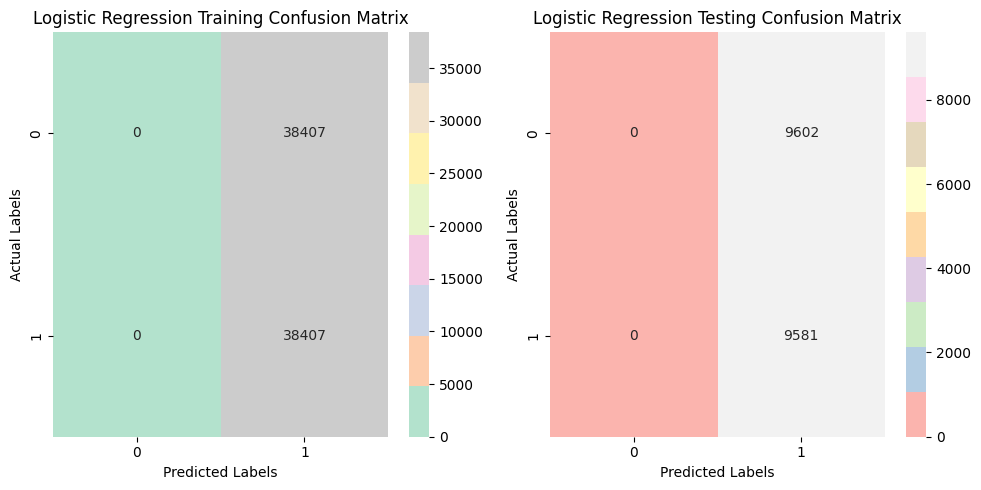

------------------------------------------------------------------------------------------------------
Train F1 Score is: 0.6666666666666666
Test F1 Score is: 0.6661799471561675
------------------------------------------------------------------------------------------------------
Logistic Regression Training Classification Report:
              precision    recall  f1-score   support

         0.0       0.00      0.00      0.00     38407
         1.0       0.50      1.00      0.67     38407

    accuracy                           0.50     76814
   macro avg       0.25      0.50      0.33     76814
weighted avg       0.25      0.50      0.33     76814

------------------------------------------------------------------------------------------------------
Logistic Regression Testing Classification Report:
              precision    recall  f1-score   support

         0.0       0.00      0.00      0.00      9602
         1.0       0.50      1.00      0.67      9581

    accuracy          

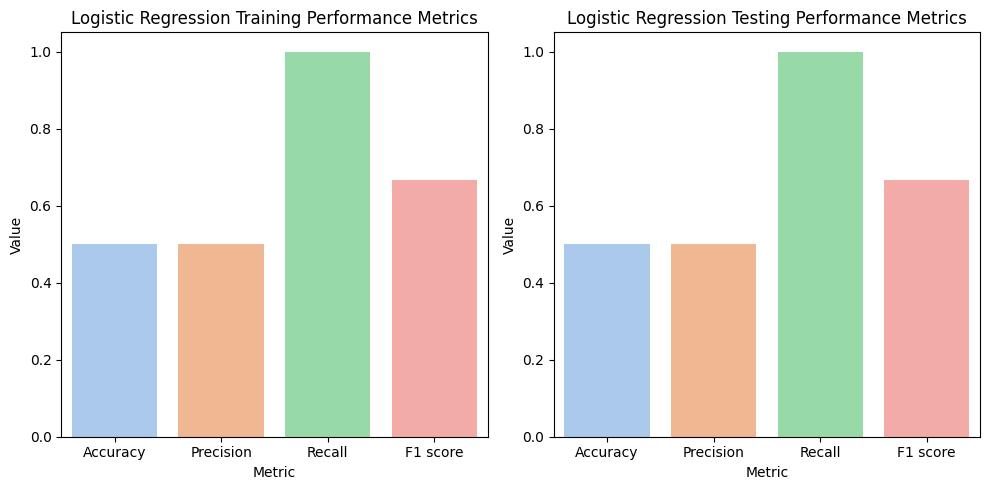

Decision Tree Classifier
------------------------------------------------------------------------------------------------------
Cross_validation Accuracy for Decision Tree Classifier :
 [0.93322052 0.93204895 0.93777662 0.93296017 0.93164952 0.93529488
 0.93828929 0.93594584 0.93685718 0.94076292]
------------------------------------------------------------------------------------------------------
------------------------------------------------------------------------------------------------------


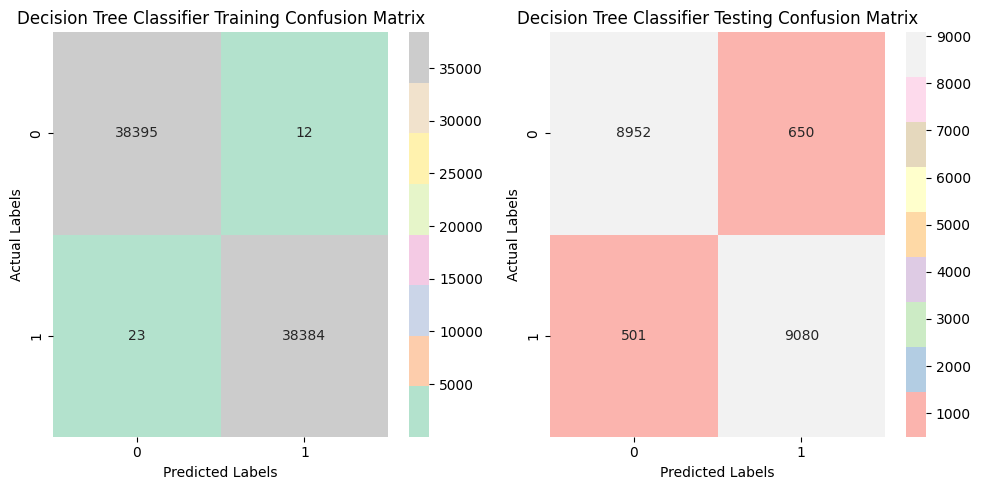

------------------------------------------------------------------------------------------------------
Train F1 Score is: 0.9995442886345586
Test F1 Score is: 0.940396665113148
------------------------------------------------------------------------------------------------------
Decision Tree Classifier Training Classification Report:
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00     38407
         1.0       1.00      1.00      1.00     38407

    accuracy                           1.00     76814
   macro avg       1.00      1.00      1.00     76814
weighted avg       1.00      1.00      1.00     76814

------------------------------------------------------------------------------------------------------
Decision Tree Classifier Testing Classification Report:
              precision    recall  f1-score   support

         0.0       0.95      0.93      0.94      9602
         1.0       0.93      0.95      0.94      9581

    accuracy 

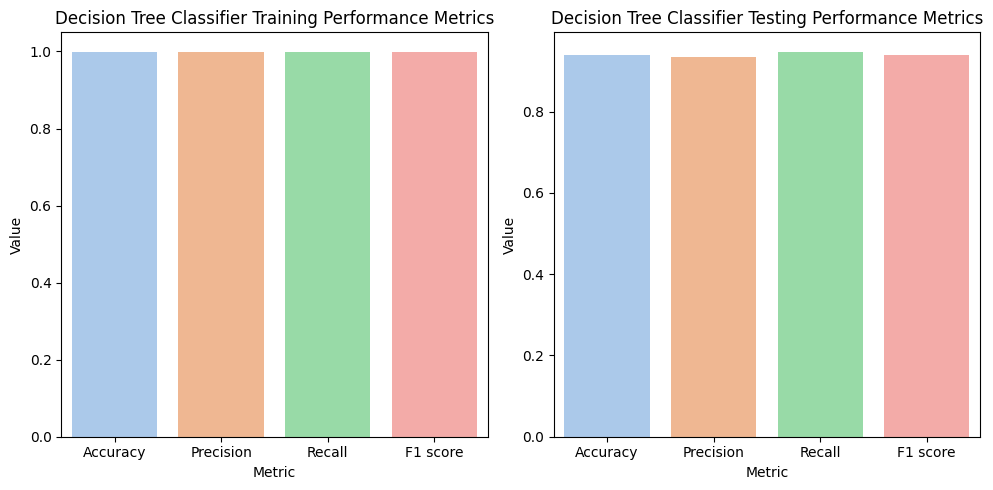

Random Forest
------------------------------------------------------------------------------------------------------
Cross_validation Accuracy for Random Forest :
 [0.95209581 0.9491018  0.95066389 0.95274668 0.94987632 0.95221976
 0.95078766 0.9546934  0.95248015 0.95274053]
------------------------------------------------------------------------------------------------------
------------------------------------------------------------------------------------------------------


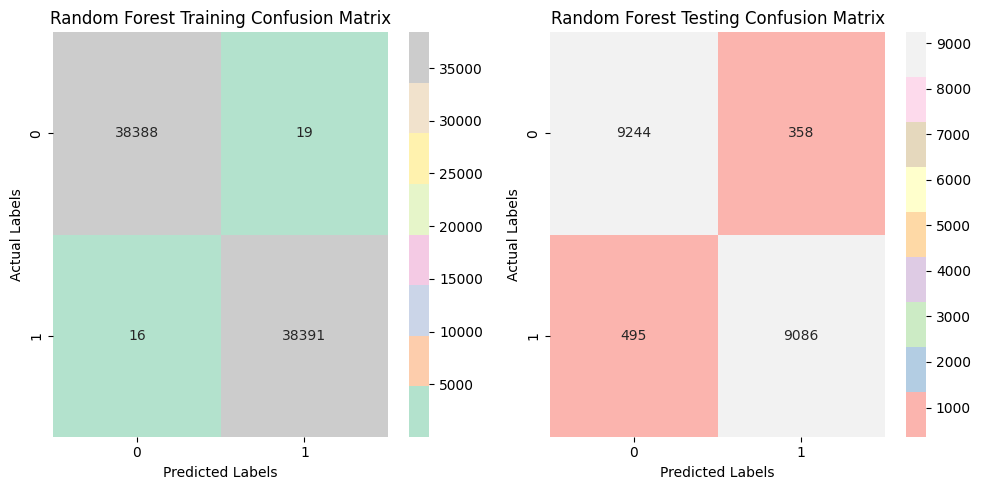

------------------------------------------------------------------------------------------------------
Train F1 Score is: 0.9995443716885586
Test F1 Score is: 0.9551642575558474
------------------------------------------------------------------------------------------------------
Random Forest Training Classification Report:
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00     38407
         1.0       1.00      1.00      1.00     38407

    accuracy                           1.00     76814
   macro avg       1.00      1.00      1.00     76814
weighted avg       1.00      1.00      1.00     76814

------------------------------------------------------------------------------------------------------
Random Forest Testing Classification Report:
              precision    recall  f1-score   support

         0.0       0.95      0.96      0.96      9602
         1.0       0.96      0.95      0.96      9581

    accuracy                      

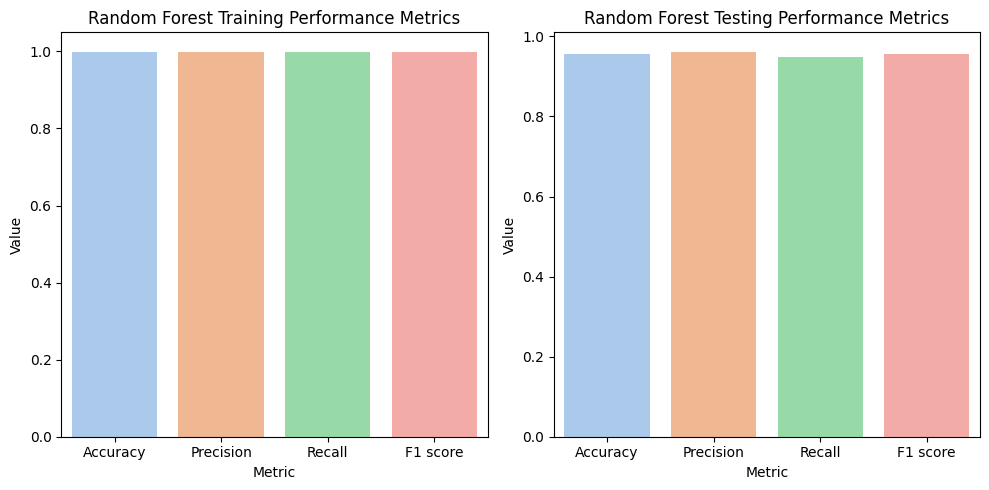

AdaBoost
------------------------------------------------------------------------------------------------------
Cross_validation Accuracy for AdaBoost :
 [0.84548295 0.84834678 0.84938818 0.85251237 0.85535738 0.84624398
 0.84468168 0.84533264 0.84181747 0.84806666]
------------------------------------------------------------------------------------------------------
------------------------------------------------------------------------------------------------------


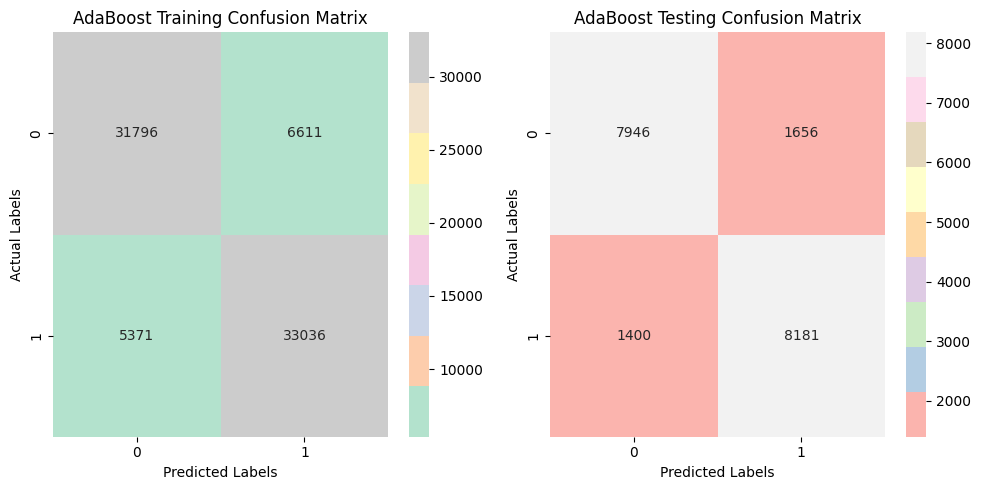

------------------------------------------------------------------------------------------------------
Train F1 Score is: 0.8464908909216696
Test F1 Score is: 0.8426202492532703
------------------------------------------------------------------------------------------------------
AdaBoost Training Classification Report:
              precision    recall  f1-score   support

         0.0       0.86      0.83      0.84     38407
         1.0       0.83      0.86      0.85     38407

    accuracy                           0.84     76814
   macro avg       0.84      0.84      0.84     76814
weighted avg       0.84      0.84      0.84     76814

------------------------------------------------------------------------------------------------------
AdaBoost Testing Classification Report:
              precision    recall  f1-score   support

         0.0       0.85      0.83      0.84      9602
         1.0       0.83      0.85      0.84      9581

    accuracy                           0.84 

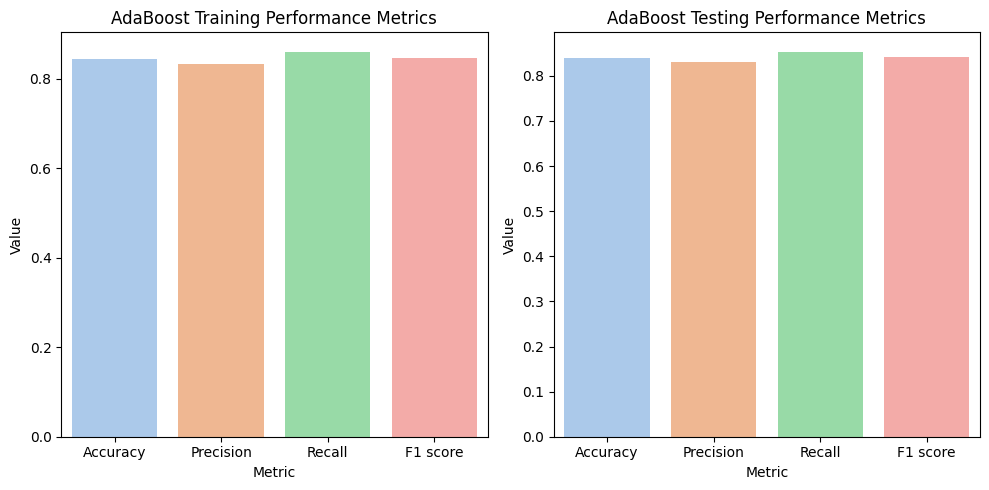

XGB Extreme X Gradient Boosting
------------------------------------------------------------------------------------------------------
Cross_validation Accuracy for XGB Extreme X Gradient Boosting :
 [0.9317886  0.92749284 0.92931528 0.93152825 0.92865512 0.93230048
 0.92826455 0.92878531 0.92657206 0.93230048]
------------------------------------------------------------------------------------------------------
------------------------------------------------------------------------------------------------------


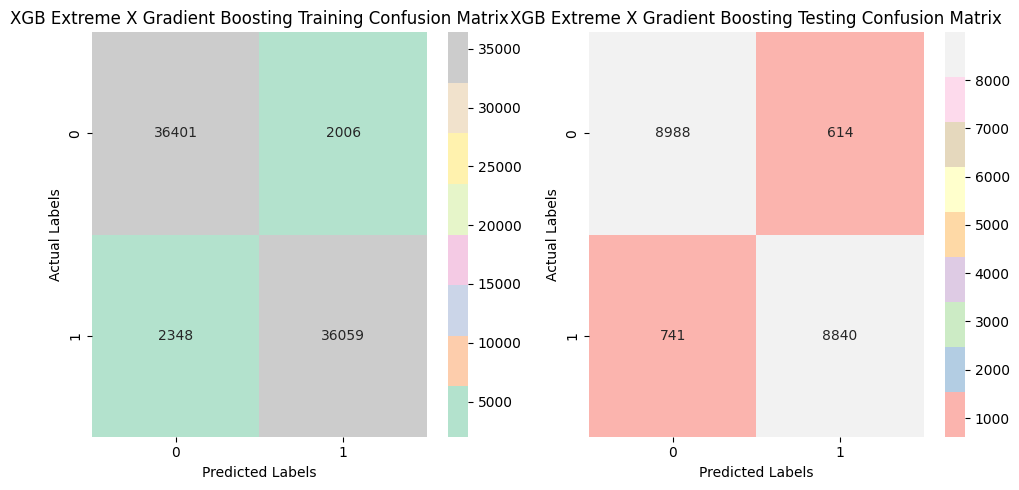

------------------------------------------------------------------------------------------------------
Train F1 Score is: 0.9430641280468669
Test F1 Score is: 0.9288153401628578
------------------------------------------------------------------------------------------------------
XGB Extreme X Gradient Boosting Training Classification Report:
              precision    recall  f1-score   support

         0.0       0.94      0.95      0.94     38407
         1.0       0.95      0.94      0.94     38407

    accuracy                           0.94     76814
   macro avg       0.94      0.94      0.94     76814
weighted avg       0.94      0.94      0.94     76814

------------------------------------------------------------------------------------------------------
XGB Extreme X Gradient Boosting Testing Classification Report:
              precision    recall  f1-score   support

         0.0       0.92      0.94      0.93      9602
         1.0       0.94      0.92      0.93      9581

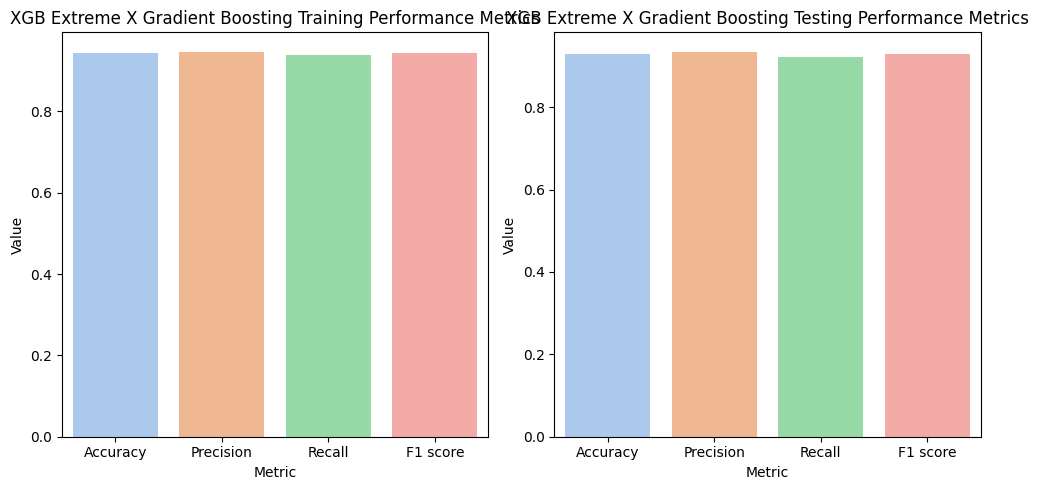

Gradient Boosting
------------------------------------------------------------------------------------------------------
Cross_validation Accuracy for Gradient Boosting :
 [0.87906795 0.87698516 0.87698516 0.88479563 0.8867335  0.88152584
 0.87566723 0.87853144 0.88100508 0.88152584]
------------------------------------------------------------------------------------------------------
------------------------------------------------------------------------------------------------------


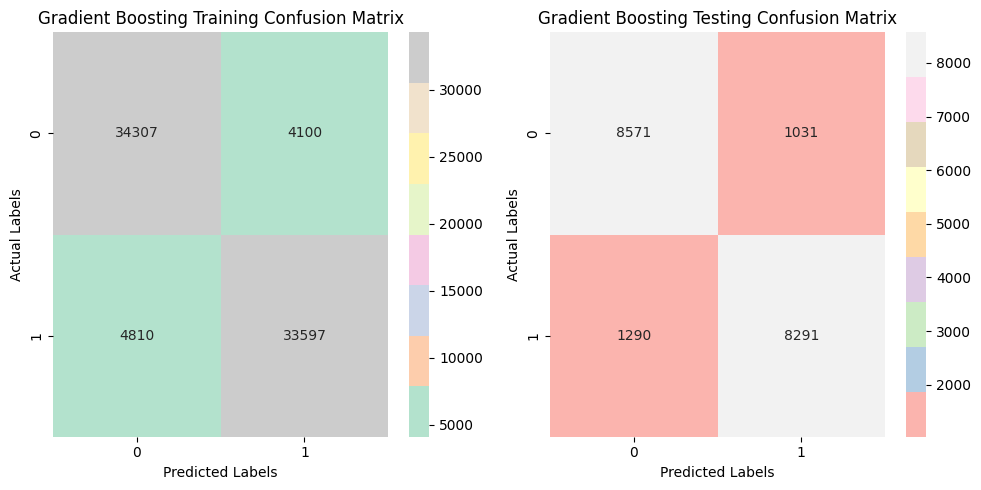

------------------------------------------------------------------------------------------------------
Train F1 Score is: 0.8829233680227058
Test F1 Score is: 0.877215256837539
------------------------------------------------------------------------------------------------------
Gradient Boosting Training Classification Report:
              precision    recall  f1-score   support

         0.0       0.88      0.89      0.89     38407
         1.0       0.89      0.87      0.88     38407

    accuracy                           0.88     76814
   macro avg       0.88      0.88      0.88     76814
weighted avg       0.88      0.88      0.88     76814

------------------------------------------------------------------------------------------------------
Gradient Boosting Testing Classification Report:
              precision    recall  f1-score   support

         0.0       0.87      0.89      0.88      9602
         1.0       0.89      0.87      0.88      9581

    accuracy               

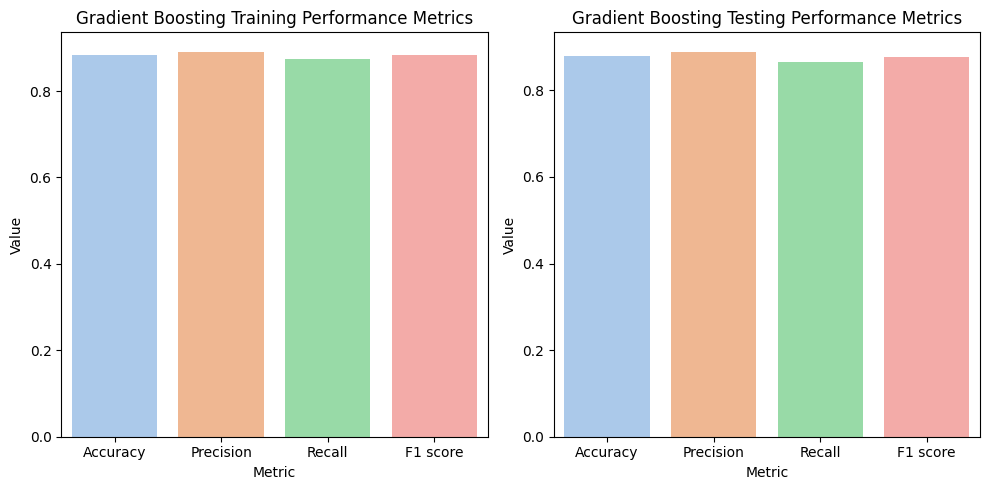

Catboost
------------------------------------------------------------------------------------------------------
Cross_validation Accuracy for Catboost :
 [0.90197865 0.89963551 0.9011976  0.90588388 0.91107929 0.90287723
 0.90261685 0.9018357  0.90456972 0.90665278]
------------------------------------------------------------------------------------------------------
------------------------------------------------------------------------------------------------------


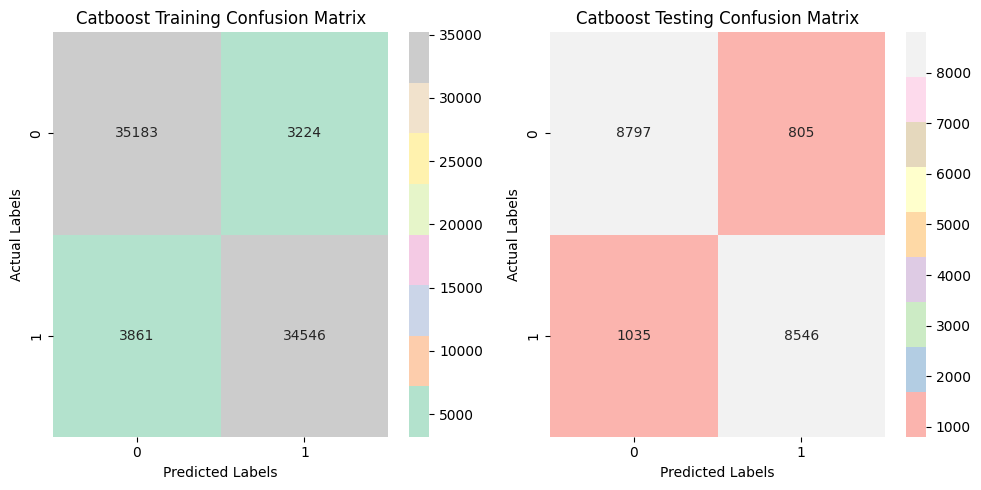

------------------------------------------------------------------------------------------------------
Train F1 Score is: 0.9069929243734985
Test F1 Score is: 0.9028100570462708
------------------------------------------------------------------------------------------------------
Catboost Training Classification Report:
              precision    recall  f1-score   support

         0.0       0.90      0.92      0.91     38407
         1.0       0.91      0.90      0.91     38407

    accuracy                           0.91     76814
   macro avg       0.91      0.91      0.91     76814
weighted avg       0.91      0.91      0.91     76814

------------------------------------------------------------------------------------------------------
Catboost Testing Classification Report:
              precision    recall  f1-score   support

         0.0       0.89      0.92      0.91      9602
         1.0       0.91      0.89      0.90      9581

    accuracy                           0.90 

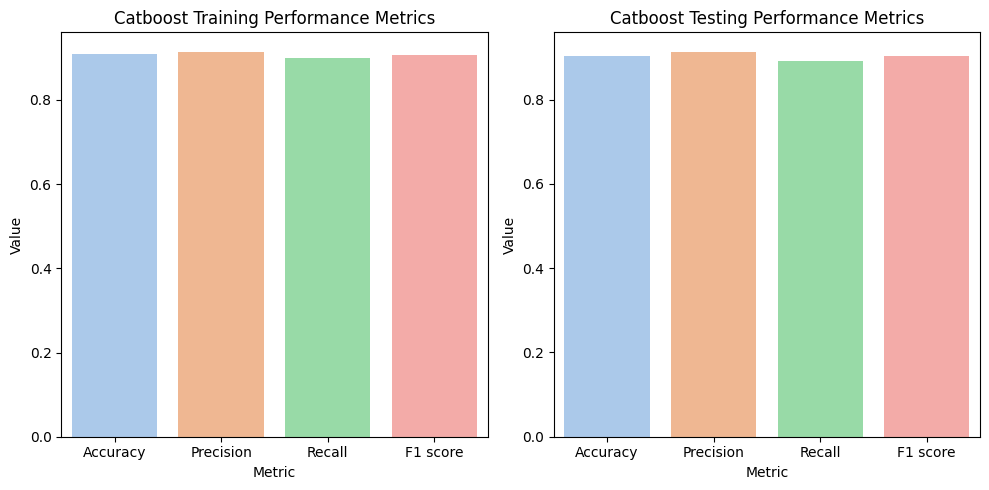

LGBM
------------------------------------------------------------------------------------------------------
Cross_validation Accuracy for LGBM :
 [0.91551679 0.9144754  0.91369435 0.9185108  0.9139435  0.91316235
 0.91212082 0.91472465 0.91042833 0.9153756 ]
------------------------------------------------------------------------------------------------------
------------------------------------------------------------------------------------------------------


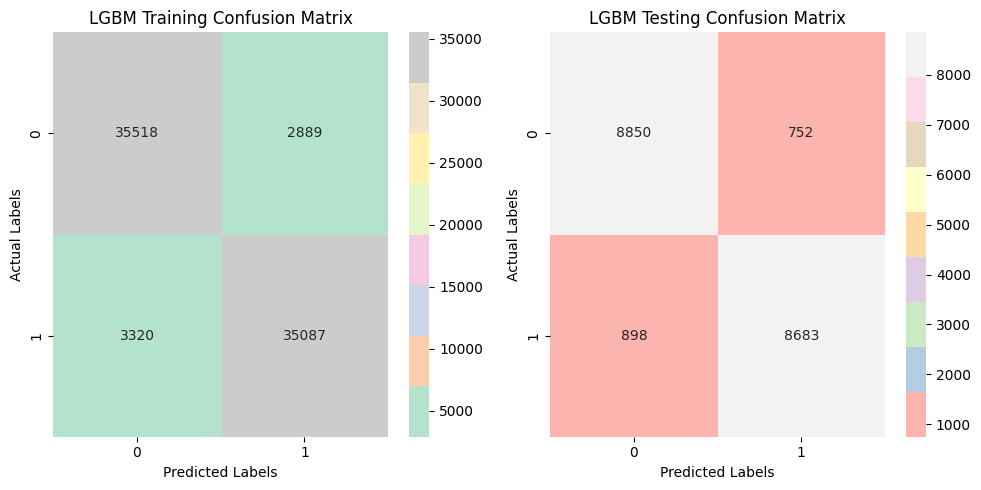

------------------------------------------------------------------------------------------------------
Train F1 Score is: 0.9187122789102288
Test F1 Score is: 0.9132309633992427
------------------------------------------------------------------------------------------------------
LGBM Training Classification Report:
              precision    recall  f1-score   support

         0.0       0.91      0.92      0.92     38407
         1.0       0.92      0.91      0.92     38407

    accuracy                           0.92     76814
   macro avg       0.92      0.92      0.92     76814
weighted avg       0.92      0.92      0.92     76814

------------------------------------------------------------------------------------------------------
LGBM Testing Classification Report:
              precision    recall  f1-score   support

         0.0       0.91      0.92      0.91      9602
         1.0       0.92      0.91      0.91      9581

    accuracy                           0.91     1918

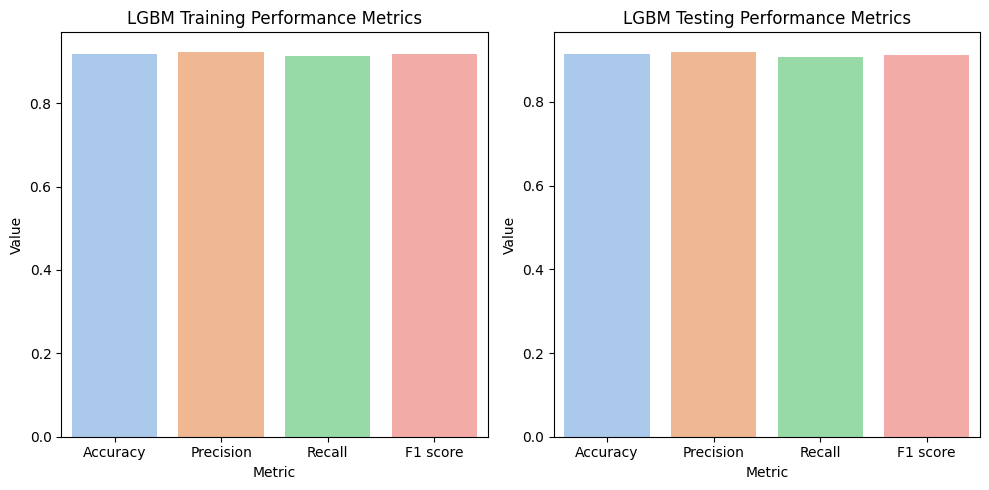

Stochastic Gradient Descent SGD
------------------------------------------------------------------------------------------------------
Cross_validation Accuracy for Stochastic Gradient Descent SGD :
 [0.62392606 0.58747722 0.57524082 0.64228066 0.62062231 0.62778284
 0.6510871  0.5000651  0.64132274 0.6268715 ]
------------------------------------------------------------------------------------------------------
------------------------------------------------------------------------------------------------------


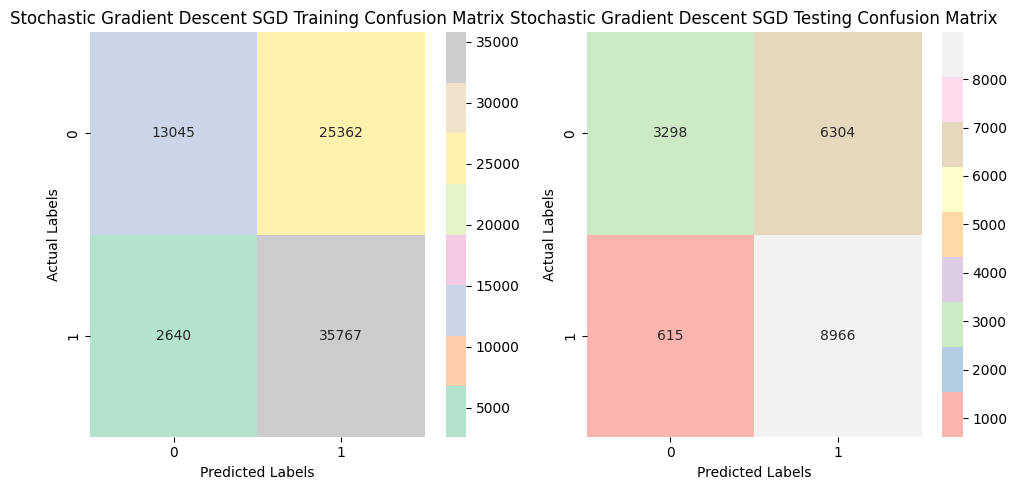

------------------------------------------------------------------------------------------------------
Train F1 Score is: 0.7186746503777528
Test F1 Score is: 0.7215806204981692
------------------------------------------------------------------------------------------------------
Stochastic Gradient Descent SGD Training Classification Report:
              precision    recall  f1-score   support

         0.0       0.83      0.34      0.48     38407
         1.0       0.59      0.93      0.72     38407

    accuracy                           0.64     76814
   macro avg       0.71      0.64      0.60     76814
weighted avg       0.71      0.64      0.60     76814

------------------------------------------------------------------------------------------------------
Stochastic Gradient Descent SGD Testing Classification Report:
              precision    recall  f1-score   support

         0.0       0.84      0.34      0.49      9602
         1.0       0.59      0.94      0.72      9581

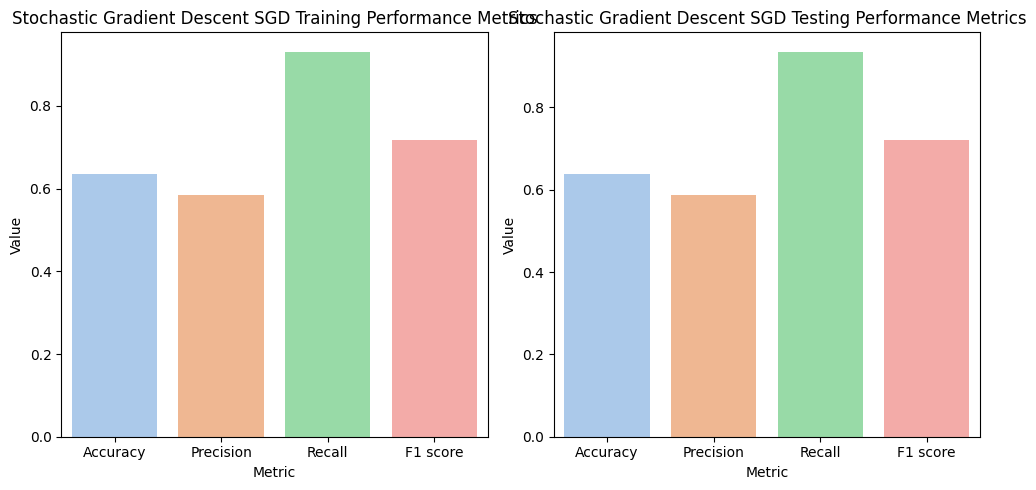

Gaussian Naive Bayes
------------------------------------------------------------------------------------------------------
Cross_validation Accuracy for Gaussian Naive Bayes :
 [0.73926061 0.74681073 0.74108305 0.75956782 0.74508528 0.74104934
 0.74365317 0.73805494 0.7508137  0.74052858]
------------------------------------------------------------------------------------------------------
------------------------------------------------------------------------------------------------------


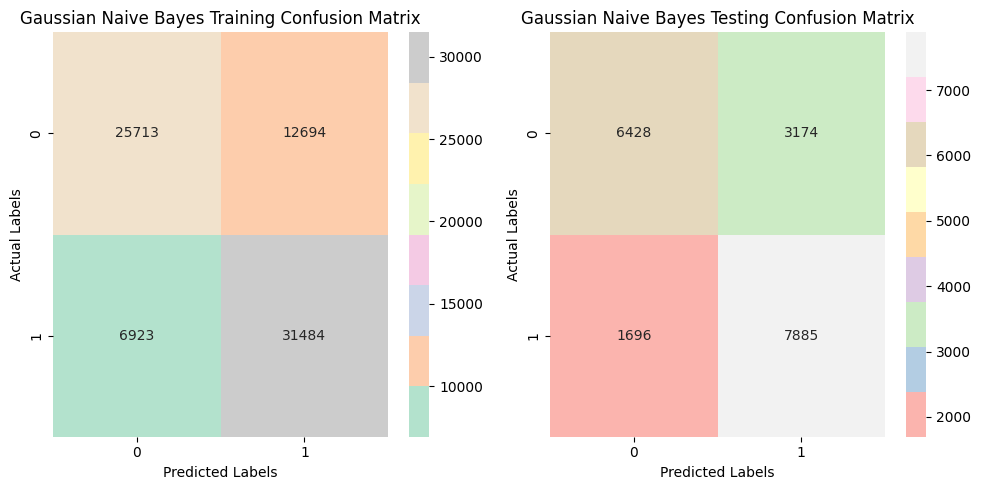

------------------------------------------------------------------------------------------------------
Train F1 Score is: 0.7624629169946116
Test F1 Score is: 0.7640503875968992
------------------------------------------------------------------------------------------------------
Gaussian Naive Bayes Training Classification Report:
              precision    recall  f1-score   support

         0.0       0.79      0.67      0.72     38407
         1.0       0.71      0.82      0.76     38407

    accuracy                           0.74     76814
   macro avg       0.75      0.74      0.74     76814
weighted avg       0.75      0.74      0.74     76814

------------------------------------------------------------------------------------------------------
Gaussian Naive Bayes Testing Classification Report:
              precision    recall  f1-score   support

         0.0       0.79      0.67      0.73      9602
         1.0       0.71      0.82      0.76      9581

    accuracy        

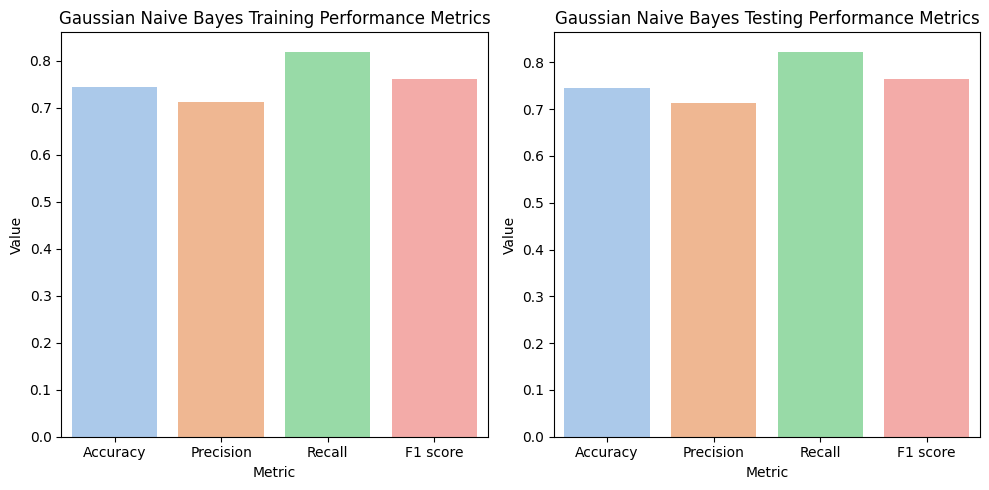

Bernoulli Naive Bayes
------------------------------------------------------------------------------------------------------
Cross_validation Accuracy for Bernoulli Naive Bayes :
 [0.74498828 0.75058578 0.7413434  0.75227805 0.7492514  0.74039839
 0.74781929 0.75094389 0.75693269 0.74847025]
------------------------------------------------------------------------------------------------------
------------------------------------------------------------------------------------------------------


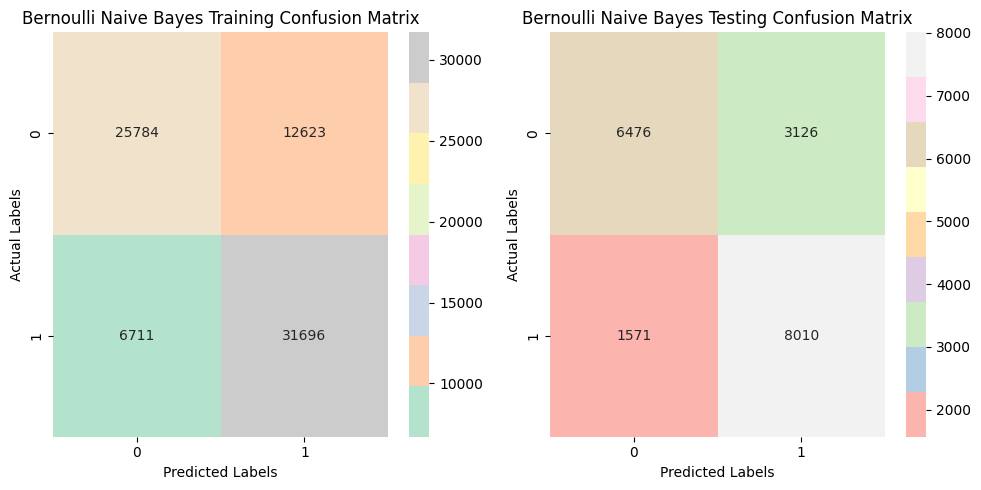

------------------------------------------------------------------------------------------------------
Train F1 Score is: 0.7662887121340328
Test F1 Score is: 0.773277984264131
------------------------------------------------------------------------------------------------------
Bernoulli Naive Bayes Training Classification Report:
              precision    recall  f1-score   support

         0.0       0.79      0.67      0.73     38407
         1.0       0.72      0.83      0.77     38407

    accuracy                           0.75     76814
   macro avg       0.75      0.75      0.75     76814
weighted avg       0.75      0.75      0.75     76814

------------------------------------------------------------------------------------------------------
Bernoulli Naive Bayes Testing Classification Report:
              precision    recall  f1-score   support

         0.0       0.80      0.67      0.73      9602
         1.0       0.72      0.84      0.77      9581

    accuracy       

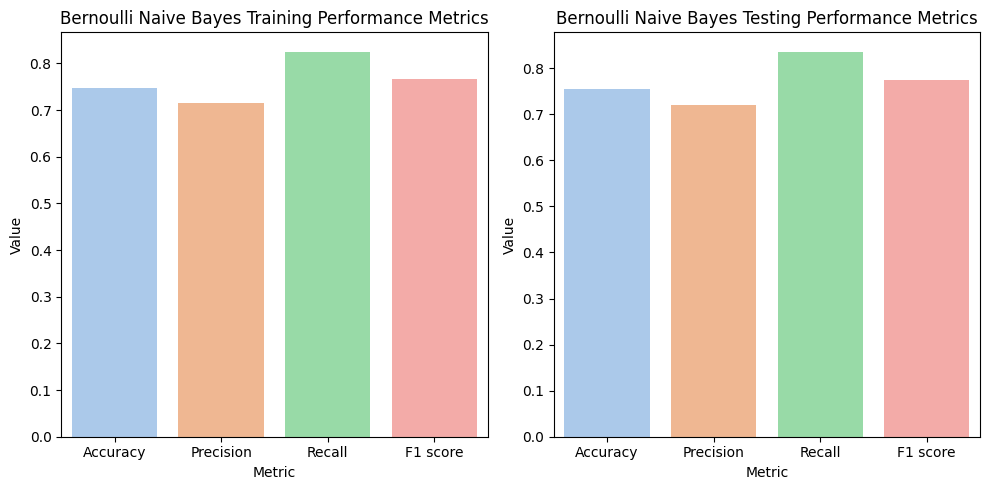

Extra Trees Classifier
------------------------------------------------------------------------------------------------------
Cross_validation Accuracy for Extra Trees Classifier :
 [0.94975267 0.94780005 0.95027337 0.95001302 0.94935555 0.95456321
 0.95104804 0.95248015 0.95117823 0.95378206]
------------------------------------------------------------------------------------------------------
------------------------------------------------------------------------------------------------------


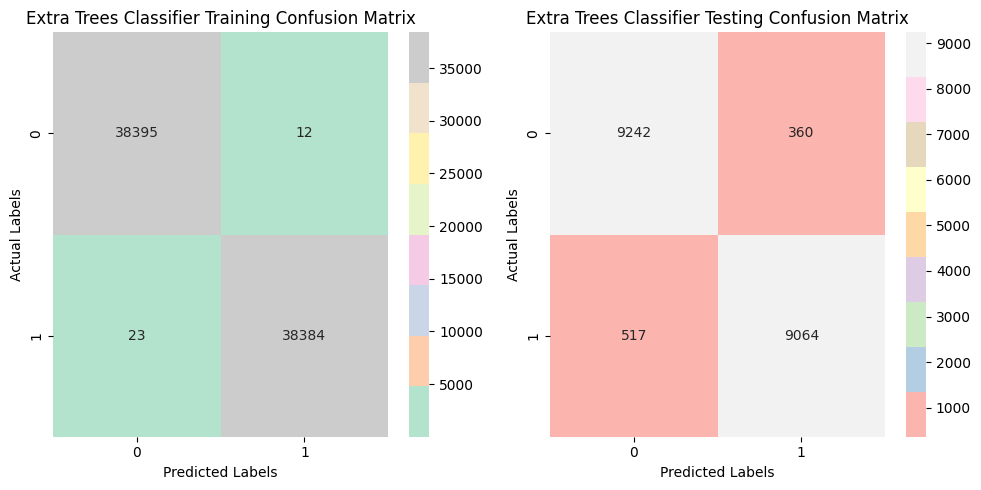

------------------------------------------------------------------------------------------------------
Train F1 Score is: 0.9995442886345586
Test F1 Score is: 0.9538542488818732
------------------------------------------------------------------------------------------------------
Extra Trees Classifier Training Classification Report:
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00     38407
         1.0       1.00      1.00      1.00     38407

    accuracy                           1.00     76814
   macro avg       1.00      1.00      1.00     76814
weighted avg       1.00      1.00      1.00     76814

------------------------------------------------------------------------------------------------------
Extra Trees Classifier Testing Classification Report:
              precision    recall  f1-score   support

         0.0       0.95      0.96      0.95      9602
         1.0       0.96      0.95      0.95      9581

    accuracy    

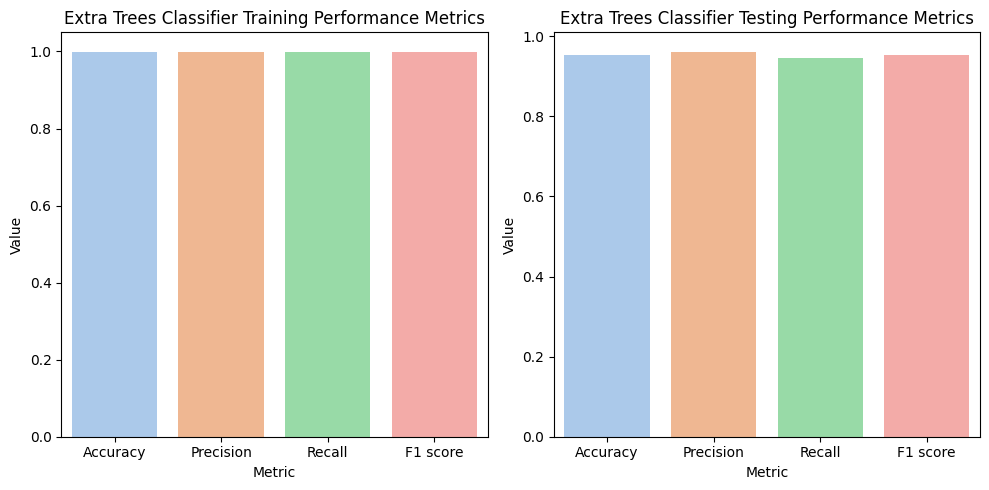

Extra Tree Classifier
------------------------------------------------------------------------------------------------------
Cross_validation Accuracy for Extra Tree Classifier :
 [0.92580057 0.9200729  0.92111429 0.92423848 0.92110402 0.92631168
 0.92474938 0.92422862 0.92527015 0.92709283]
------------------------------------------------------------------------------------------------------
------------------------------------------------------------------------------------------------------


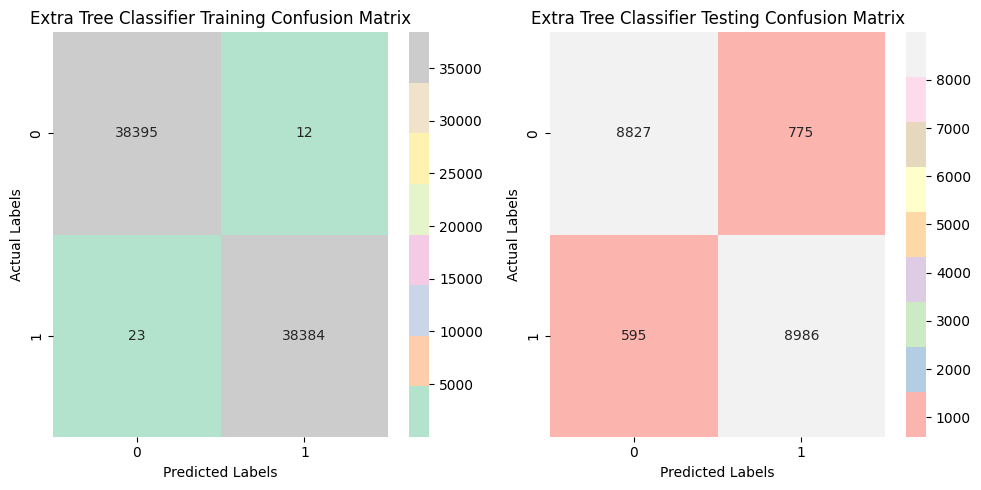

------------------------------------------------------------------------------------------------------
Train F1 Score is: 0.9995442886345586
Test F1 Score is: 0.9291696825560956
------------------------------------------------------------------------------------------------------
Extra Tree Classifier Training Classification Report:
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00     38407
         1.0       1.00      1.00      1.00     38407

    accuracy                           1.00     76814
   macro avg       1.00      1.00      1.00     76814
weighted avg       1.00      1.00      1.00     76814

------------------------------------------------------------------------------------------------------
Extra Tree Classifier Testing Classification Report:
              precision    recall  f1-score   support

         0.0       0.94      0.92      0.93      9602
         1.0       0.92      0.94      0.93      9581

    accuracy      

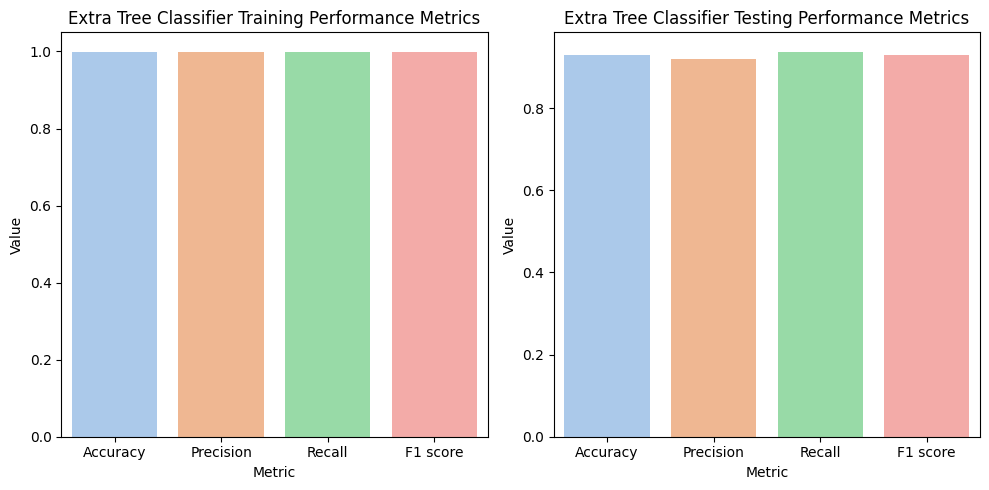

K Nearest Neighbors
------------------------------------------------------------------------------------------------------
Cross_validation Accuracy for K Nearest Neighbors :
 [0.91486592 0.90861755 0.9190315  0.91161156 0.91003776 0.92071345
 0.91498503 0.91068871 0.91316235 0.91563598]
------------------------------------------------------------------------------------------------------
------------------------------------------------------------------------------------------------------


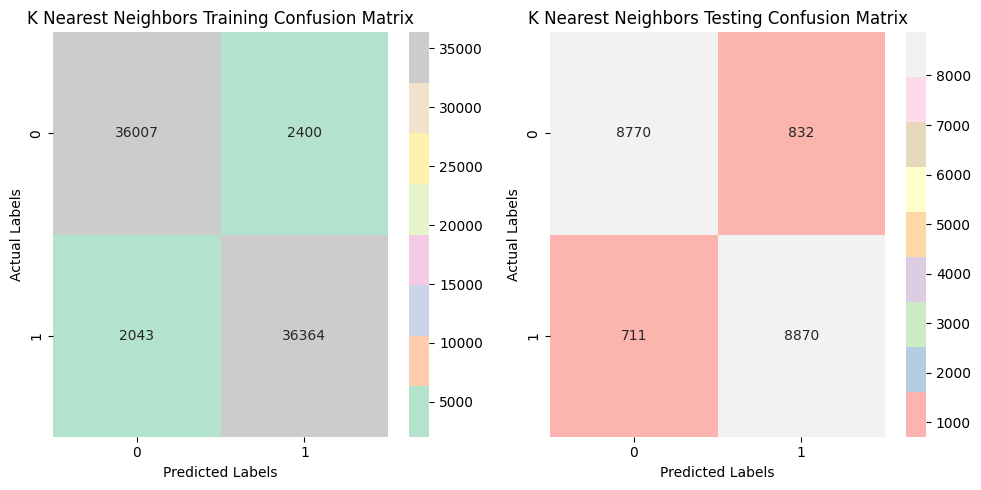

------------------------------------------------------------------------------------------------------
Train F1 Score is: 0.9424265591996993
Test F1 Score is: 0.9199813307058031
------------------------------------------------------------------------------------------------------
K Nearest Neighbors Training Classification Report:
              precision    recall  f1-score   support

         0.0       0.95      0.94      0.94     38407
         1.0       0.94      0.95      0.94     38407

    accuracy                           0.94     76814
   macro avg       0.94      0.94      0.94     76814
weighted avg       0.94      0.94      0.94     76814

------------------------------------------------------------------------------------------------------
K Nearest Neighbors Testing Classification Report:
              precision    recall  f1-score   support

         0.0       0.93      0.91      0.92      9602
         1.0       0.91      0.93      0.92      9581

    accuracy          

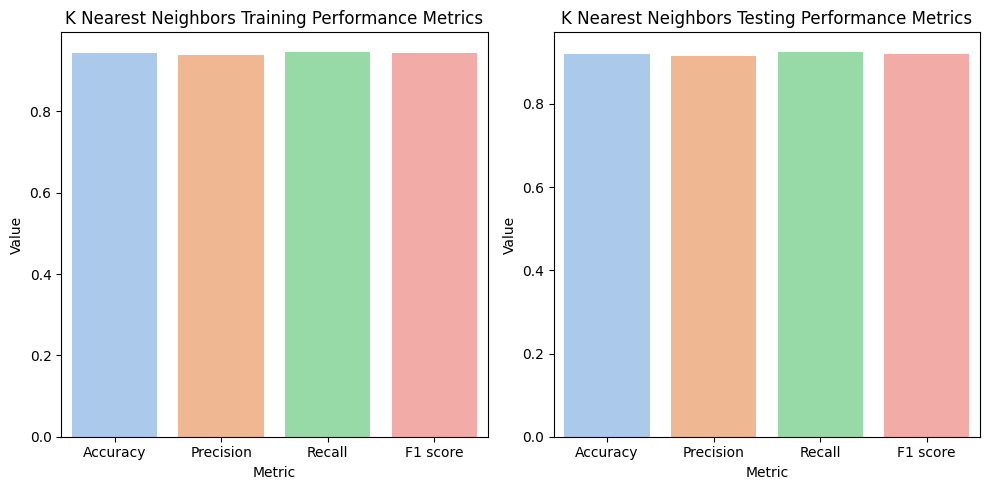

Bagging Classifier
------------------------------------------------------------------------------------------------------
Cross_validation Accuracy for Bagging Classifier :
 [0.94714918 0.94584744 0.94819058 0.94714918 0.94440828 0.94558
 0.94518943 0.94831402 0.94753287 0.95274053]
------------------------------------------------------------------------------------------------------
------------------------------------------------------------------------------------------------------


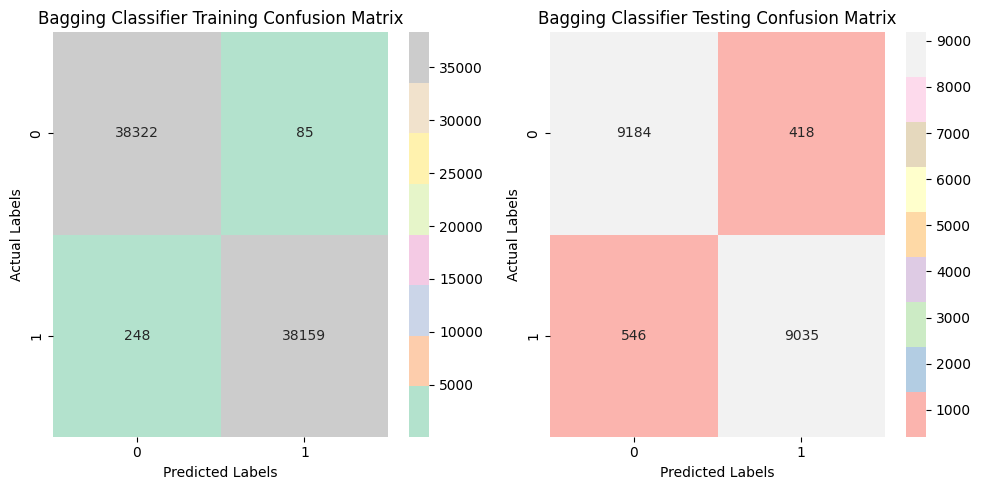

------------------------------------------------------------------------------------------------------
Train F1 Score is: 0.995655633977378
Test F1 Score is: 0.9493537879583902
------------------------------------------------------------------------------------------------------
Bagging Classifier Training Classification Report:
              precision    recall  f1-score   support

         0.0       0.99      1.00      1.00     38407
         1.0       1.00      0.99      1.00     38407

    accuracy                           1.00     76814
   macro avg       1.00      1.00      1.00     76814
weighted avg       1.00      1.00      1.00     76814

------------------------------------------------------------------------------------------------------
Bagging Classifier Testing Classification Report:
              precision    recall  f1-score   support

         0.0       0.94      0.96      0.95      9602
         1.0       0.96      0.94      0.95      9581

    accuracy             

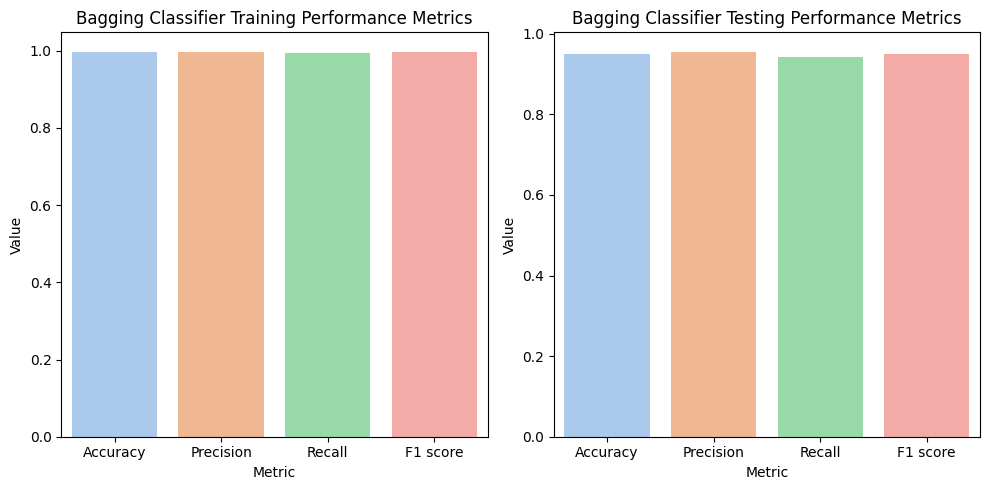

In [33]:
# Assuming you have your data loaded into X_train, y_train, X_test, and y_test
models,classifiers = Classifiers(X_train_resampled, y_train_resampled, X_test, y_test)

#6. Apply Stacking Classifier and Soft Voting and compare the results with the champion model as a new approach in this project.

#### Calculate the TP , TN and F1_score(average='macro') for all models  

In [34]:
models_results={}
models_predictions={}
for clf_name, clf in models.items():


    y_test_pred = clf.predict(X_test)
    f1_test = f1_score(y_test, y_test_pred, average='macro')
    ##############################################################################################################
    # Confusion Matrix for Training and Testing
    tn, fp, fn, tp = confusion_matrix(y_test, y_test_pred).ravel()
    models_results[clf_name] = {'TP': tp, 'TN': tn, 'f1': f1_test, 'y_test_pred': y_test_pred}
    models_predictions[clf_name] = {'y_test_pred': y_test_pred}
    print(f"{clf_name} Results:\n", models_results[clf_name])
    print("------------------------------------------------------------------------------------------------------")
    print("------------------------------------------------------------------------------------------------------")

Logistic Regression Results:
 {'TP': 9581, 'TN': 0, 'f1': 0.33308997357808373, 'y_test_pred': array([1., 1., 1., ..., 1., 1., 1.])}
------------------------------------------------------------------------------------------------------
------------------------------------------------------------------------------------------------------
Decision Tree Classifier Results:
 {'TP': 9080, 'TN': 8952, 'f1': 0.9399962858496729, 'y_test_pred': array([1., 0., 1., ..., 0., 0., 1.])}
------------------------------------------------------------------------------------------------------
------------------------------------------------------------------------------------------------------
Random Forest Results:
 {'TP': 9086, 'TN': 9244, 'f1': 0.9555305285504277, 'y_test_pred': array([0., 0., 1., ..., 0., 0., 1.])}
------------------------------------------------------------------------------------------------------
--------------------------------------------------------------------------------------

#### Find the Champion Model

In [35]:
# Display the champion model based on F1 score
sorted_results_f1 = sorted(models_results.items(), key=lambda x: x[1]['f1'], reverse=True)
champion_model, champion_metrics = sorted_results_f1[0]

# Create a DataFrame for the champion model
df_champion = pd.DataFrame({'Model': [champion_model], 'F1_Score': [champion_metrics['f1']]})

# Display the DataFrame
print("\nChampion Model based on F1_Score:")
# print(df_champion)
df_champion


Champion Model based on F1_Score:


,Model,F1_Score
0,Random Forest,0.955531


#### Sort the Models Results in Descending Order Based on TP

In [36]:
# Display the results in descending order based on tp_test
sorted_results_tp = sorted(models_results.items(), key=lambda x: x[1]['TP'], reverse=True)

# Create a DataFrame from the results
df_tp = pd.DataFrame(sorted_results_tp, columns=['Model', 'Models Results in Descending Order based on TP'])

# If you want to add styling, you can use the following:
styled_table_tp = df_tp.style.background_gradient(cmap='Blues')
# display(styled_table_tp)
styled_table_tp

,Model,Models Results in Descending Order based on TP
0,Logistic Regression,"{'TP': 9581, 'TN': 0, 'f1': 0.33308997357808373, 'y_test_pred': array([1., 1., 1., ..., 1., 1., 1.])}"
1,Random Forest,"{'TP': 9086, 'TN': 9244, 'f1': 0.9555305285504277, 'y_test_pred': array([0., 0., 1., ..., 0., 0., 1.])}"
2,Decision Tree Classifier,"{'TP': 9080, 'TN': 8952, 'f1': 0.9399962858496729, 'y_test_pred': array([1., 0., 1., ..., 0., 0., 1.])}"
3,Extra Trees Classifier,"{'TP': 9064, 'TN': 9242, 'f1': 0.9542785009194243, 'y_test_pred': array([0., 0., 1., ..., 0., 0., 1.])}"
4,Bagging Classifier,"{'TP': 9035, 'TN': 9184, 'f1': 0.9497441399961618, 'y_test_pred': array([0., 0., 1., ..., 0., 0., 1.])}"
5,Extra Tree Classifier,"{'TP': 8986, 'TN': 8827, 'f1': 0.9285776924134557, 'y_test_pred': array([0., 0., 1., ..., 0., 0., 1.])}"
6,Stochastic Gradient Descent SGD,"{'TP': 8966, 'TN': 3298, 'f1': 0.6048154674817889, 'y_test_pred': array([1., 1., 1., ..., 1., 1., 1.])}"
7,K Nearest Neighbors,"{'TP': 8870, 'TN': 8770, 'f1': 0.9195620115772898, 'y_test_pred': array([0., 0., 1., ..., 0., 0., 1.])}"
8,XGB Extreme X Gradient Boosting,"{'TP': 8840, 'TN': 8988, 'f1': 0.9293603367825826, 'y_test_pred': array([0, 0, 1, ..., 0, 0, 0])}"
9,LGBM,"{'TP': 8683, 'TN': 8850, 'f1': 0.9139798227848928, 'y_test_pred': array([0., 0., 1., ..., 0., 0., 0.])}"


#### Sort the Models Results in Descending Order Based on TN

In [37]:
# Assuming models_results is a dictionary where each entry is {model_name: {'TN': value, ...}}
sorted_results_tn = sorted(models_results.items(), key=lambda x: x[1]['TN'], reverse=True)

# Create a DataFrame from the results
df_tn = pd.DataFrame(sorted_results_tn, columns=['Model', 'Models Results in Descending Order based on TN'])

# If you want to add styling, you can use the following:
styled_table_tn = df_tn.style.background_gradient(cmap='Blues')
# display(styled_table_tn)
styled_table_tn

,Model,Models Results in Descending Order based on TN
0,Random Forest,"{'TP': 9086, 'TN': 9244, 'f1': 0.9555305285504277, 'y_test_pred': array([0., 0., 1., ..., 0., 0., 1.])}"
1,Extra Trees Classifier,"{'TP': 9064, 'TN': 9242, 'f1': 0.9542785009194243, 'y_test_pred': array([0., 0., 1., ..., 0., 0., 1.])}"
2,Bagging Classifier,"{'TP': 9035, 'TN': 9184, 'f1': 0.9497441399961618, 'y_test_pred': array([0., 0., 1., ..., 0., 0., 1.])}"
3,XGB Extreme X Gradient Boosting,"{'TP': 8840, 'TN': 8988, 'f1': 0.9293603367825826, 'y_test_pred': array([0, 0, 1, ..., 0, 0, 0])}"
4,Decision Tree Classifier,"{'TP': 9080, 'TN': 8952, 'f1': 0.9399962858496729, 'y_test_pred': array([1., 0., 1., ..., 0., 0., 1.])}"
5,LGBM,"{'TP': 8683, 'TN': 8850, 'f1': 0.9139798227848928, 'y_test_pred': array([0., 0., 1., ..., 0., 0., 0.])}"
6,Extra Tree Classifier,"{'TP': 8986, 'TN': 8827, 'f1': 0.9285776924134557, 'y_test_pred': array([0., 0., 1., ..., 0., 0., 1.])}"
7,Catboost,"{'TP': 8546, 'TN': 8797, 'f1': 0.9040653146196672, 'y_test_pred': array([0., 0., 1., ..., 0., 0., 0.])}"
8,K Nearest Neighbors,"{'TP': 8870, 'TN': 8770, 'f1': 0.9195620115772898, 'y_test_pred': array([0., 0., 1., ..., 0., 0., 1.])}"
9,Gradient Boosting,"{'TP': 8291, 'TN': 8571, 'f1': 0.8789816714748246, 'y_test_pred': array([0., 0., 1., ..., 0., 0., 0.])}"


#### Sort the Models Results in Descending Order Based on F1_Score

In [38]:
# Display the results in descending order based on f1 score
sorted_results_f1 = sorted(models_results.items(), key=lambda x: x[1]['f1'], reverse=True)

# Create a DataFrame from the results
df_f1 = pd.DataFrame(sorted_results_f1, columns=['Model', 'Models Results in Descending Order based on F1_Score'])

# If you want to add styling, you can use the following:
styled_table_f1 = df_f1.style.background_gradient(cmap='Blues')
# display(styled_table_f1)
styled_table_f1

,Model,Models Results in Descending Order based on F1_Score
0,Random Forest,"{'TP': 9086, 'TN': 9244, 'f1': 0.9555305285504277, 'y_test_pred': array([0., 0., 1., ..., 0., 0., 1.])}"
1,Extra Trees Classifier,"{'TP': 9064, 'TN': 9242, 'f1': 0.9542785009194243, 'y_test_pred': array([0., 0., 1., ..., 0., 0., 1.])}"
2,Bagging Classifier,"{'TP': 9035, 'TN': 9184, 'f1': 0.9497441399961618, 'y_test_pred': array([0., 0., 1., ..., 0., 0., 1.])}"
3,Decision Tree Classifier,"{'TP': 9080, 'TN': 8952, 'f1': 0.9399962858496729, 'y_test_pred': array([1., 0., 1., ..., 0., 0., 1.])}"
4,XGB Extreme X Gradient Boosting,"{'TP': 8840, 'TN': 8988, 'f1': 0.9293603367825826, 'y_test_pred': array([0, 0, 1, ..., 0, 0, 0])}"
5,Extra Tree Classifier,"{'TP': 8986, 'TN': 8827, 'f1': 0.9285776924134557, 'y_test_pred': array([0., 0., 1., ..., 0., 0., 1.])}"
6,K Nearest Neighbors,"{'TP': 8870, 'TN': 8770, 'f1': 0.9195620115772898, 'y_test_pred': array([0., 0., 1., ..., 0., 0., 1.])}"
7,LGBM,"{'TP': 8683, 'TN': 8850, 'f1': 0.9139798227848928, 'y_test_pred': array([0., 0., 1., ..., 0., 0., 0.])}"
8,Catboost,"{'TP': 8546, 'TN': 8797, 'f1': 0.9040653146196672, 'y_test_pred': array([0., 0., 1., ..., 0., 0., 0.])}"
9,Gradient Boosting,"{'TP': 8291, 'TN': 8571, 'f1': 0.8789816714748246, 'y_test_pred': array([0., 0., 1., ..., 0., 0., 0.])}"


#### Select the best two models in TP

In [39]:
top_models_tp = sorted_results_tp[:5]
# Create a DataFrame from the results
df_tp = pd.DataFrame(top_models_tp, columns=['Model', 'Sort by Tp_Score'])
styled_table_tp = df_tp.style.background_gradient(cmap='Blues')
# display(styled_table_tp)
styled_table_tp

,Model,Sort by Tp_Score
0,Logistic Regression,"{'TP': 9581, 'TN': 0, 'f1': 0.33308997357808373, 'y_test_pred': array([1., 1., 1., ..., 1., 1., 1.])}"
1,Random Forest,"{'TP': 9086, 'TN': 9244, 'f1': 0.9555305285504277, 'y_test_pred': array([0., 0., 1., ..., 0., 0., 1.])}"
2,Decision Tree Classifier,"{'TP': 9080, 'TN': 8952, 'f1': 0.9399962858496729, 'y_test_pred': array([1., 0., 1., ..., 0., 0., 1.])}"
3,Extra Trees Classifier,"{'TP': 9064, 'TN': 9242, 'f1': 0.9542785009194243, 'y_test_pred': array([0., 0., 1., ..., 0., 0., 1.])}"
4,Bagging Classifier,"{'TP': 9035, 'TN': 9184, 'f1': 0.9497441399961618, 'y_test_pred': array([0., 0., 1., ..., 0., 0., 1.])}"


#### Select the best two models in TN

In [40]:
top_models_tn = sorted_results_tn[:5]
# Create a DataFrame from the results
df_tn = pd.DataFrame(top_models_tn, columns=['Model', 'Sort by Tn_Score'])
styled_table_tn = df_tn.style.background_gradient(cmap='Blues')
# display(styled_table_tn)
styled_table_tn

,Model,Sort by Tn_Score
0,Random Forest,"{'TP': 9086, 'TN': 9244, 'f1': 0.9555305285504277, 'y_test_pred': array([0., 0., 1., ..., 0., 0., 1.])}"
1,Extra Trees Classifier,"{'TP': 9064, 'TN': 9242, 'f1': 0.9542785009194243, 'y_test_pred': array([0., 0., 1., ..., 0., 0., 1.])}"
2,Bagging Classifier,"{'TP': 9035, 'TN': 9184, 'f1': 0.9497441399961618, 'y_test_pred': array([0., 0., 1., ..., 0., 0., 1.])}"
3,XGB Extreme X Gradient Boosting,"{'TP': 8840, 'TN': 8988, 'f1': 0.9293603367825826, 'y_test_pred': array([0, 0, 1, ..., 0, 0, 0])}"
4,Decision Tree Classifier,"{'TP': 9080, 'TN': 8952, 'f1': 0.9399962858496729, 'y_test_pred': array([1., 0., 1., ..., 0., 0., 1.])}"


#### Select the best two models in F1_Score

In [41]:
top_models_f1 = sorted_results_f1[:5]
# Create a DataFrame from the results
df_f1 = pd.DataFrame(top_models_f1, columns=['Model', 'Sort by F1_Score'])
styled_table_f1 = df_f1.style.background_gradient(cmap='Blues')
# display(styled_table_f1)
styled_table_f1

,Model,Sort by F1_Score
0,Random Forest,"{'TP': 9086, 'TN': 9244, 'f1': 0.9555305285504277, 'y_test_pred': array([0., 0., 1., ..., 0., 0., 1.])}"
1,Extra Trees Classifier,"{'TP': 9064, 'TN': 9242, 'f1': 0.9542785009194243, 'y_test_pred': array([0., 0., 1., ..., 0., 0., 1.])}"
2,Bagging Classifier,"{'TP': 9035, 'TN': 9184, 'f1': 0.9497441399961618, 'y_test_pred': array([0., 0., 1., ..., 0., 0., 1.])}"
3,Decision Tree Classifier,"{'TP': 9080, 'TN': 8952, 'f1': 0.9399962858496729, 'y_test_pred': array([1., 0., 1., ..., 0., 0., 1.])}"
4,XGB Extreme X Gradient Boosting,"{'TP': 8840, 'TN': 8988, 'f1': 0.9293603367825826, 'y_test_pred': array([0, 0, 1, ..., 0, 0, 0])}"


# 7.Apply Fusion Classifier

#### Apply Stacking Classifier on the best two models in TP

In [42]:
# Initialize the base models
base_models = [
    # ("Stochastic Gradient Descent SGD", SGDClassifier(loss='modified_huber', random_state=42)),
    ("XGB Extreme X Gradient Boosting", XGBClassifier(use_label_encoder=False)),
    ("LGBM", LGBMClassifier(random_state=42)),
]

#Initialize the stacking classifier with the meta-model
stacking_classifier1 = StackingClassifier(
    estimators=base_models,
    final_estimator=LogisticRegression(random_state=42)
)

# Fit the stacking classifier on the training data
stacking_classifier1.fit(X_train_resampled, y_train_resampled)

StackingClassifier(estimators=[('XGB Extreme X Gradient Boosting',
                                XGBClassifier(base_score=None, booster=None,
                                              callbacks=None,
                                              colsample_bylevel=None,
                                              colsample_bynode=None,
                                              colsample_bytree=None,
                                              device=None,
                                              early_stopping_rounds=None,
                                              enable_categorical=False,
                                              eval_metric=None,
                                              feature_types=None,
                                              feature_weights=None, gamma=None,
                                              grow_policy=None,
                                              importance_typ...
                                              learning_rate=None, max_bin=None,
                                              max_cat_threshold=None,
                                              max_cat_to_onehot=None,
                                              max_delta_step=None,
                                              max_depth=None, max_leaves=None,
                                              min_child_weight=None,
                                              missing=nan,
                                              monotone_constraints=None,
                                              multi_strategy=None,
                                              n_estimators=None, n_jobs=None,
                                              num_parallel_tree=None, ...)),
                               ('LGBM', LGBMClassifier(random_state=42))],
                   final_estimator=LogisticRegression(random_state=42))

#### Apply Stacking Classifier on the best two models in TN

In [43]:
# Initialize the base models
base_models = [
    ("Gradient Boosting", GradientBoostingClassifier(n_estimators=100, random_state=42)),
    ("Gaussian Naive Bayes", GaussianNB())
    # ("Bagging Classifier", BaggingClassifier(base_estimator=DecisionTreeClassifier(random_state=42), n_estimators=100, random_state=42)),
]

#Initialize the stacking classifier with the meta-model
stacking_classifier = StackingClassifier(
    estimators=base_models,
    final_estimator=LogisticRegression(random_state=42)
)

# Fit the stacking classifier on the training data
stacking_classifier.fit(X_train_resampled, y_train_resampled)

StackingClassifier(estimators=[('Gradient Boosting',
                                GradientBoostingClassifier(random_state=42)),
                               ('Gaussian Naive Bayes', GaussianNB())],
                   final_estimator=LogisticRegression(random_state=42))

#### Apply soft voting to the results of the Stacking Classifier for both TP and TN.

In [44]:
# Create the ensemble model using soft voting
ensemble_classifier = VotingClassifier(estimators=[
    ("tn", stacking_classifier),
    ("tp", stacking_classifier1),
], voting='soft')

# Fit the ensemble model on the training data
ensemble_classifier.fit(X_train_resampled, y_train_resampled)

# Make predictions on the validation data
y_pred_ensemble = ensemble_classifier.predict(X_test)

In [45]:
f1_test = f1_score(y_test, y_pred_ensemble, average='macro')
tn, fp, fn, tp = confusion_matrix(y_test, y_pred_ensemble).ravel()
print(f"f1:{f1_test}")

f1:0.9190924198432197


#### Compare the results.

##### As shown here, the results of soft voting after selecting best of TP and TN are better than the champion model.

In [46]:
# Create a DataFrame for the ensemble classifier
df_ensemble = pd.DataFrame({'Model': ['Ensemble Classifier'], 'F1_Score': [f1_test]})

# Display the DataFrame for the ensemble classifier
print("\nEnsemble Classifier based on F1_Score:")
print(df_ensemble)

# Compare the results in a single DataFrame
df_comparison = pd.concat([df_champion, df_ensemble], ignore_index=True)

# Display the comparison DataFrame
print("\nComparison of Champion Model and Ensemble Classifier:")
# print(df_comparison)
df_comparison


Ensemble Classifier based on F1_Score:
                 Model  F1_Score
0  Ensemble Classifier  0.919092

Comparison of Champion Model and Ensemble Classifier:


,Model,F1_Score
0,Random Forest,0.955531
1,Ensemble Classifier,0.919092
